# Hidden Market States: Financial Market Regime Detection Using Hidden Markov Models
**A Probabilistic Sequence-Modelling Approach to Detecting Bull, Bear, and Sideways Market Regimes**

## 1. Introduction & Objective
Financial markets are commonly treated as noisy, unstructured sequences of price observations[cite: 1]. This project proposes an alternative view: that the apparent complexity of market behaviour can, to a meaningful extent, be explained by a small number of latent behavioural regimes — conventionally described as Bull, Bear, and Sideways markets[cite: 1].

In this notebook, we model the market as a Hidden Markov Model (HMM)[cite: 1]. Before building the Forward-Backward and Baum-Welch algorithms from first principles, we must construct a mathematically sound observation matrix. We will ingest historical S&P 500 data and engineer specific continuous features that capture market dynamics[cite: 1].

In [11]:
# Import necessary libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set plotting style for professional, high-definition academic visualizations
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 300

## 2. Data Ingestion and Heavy Preprocessing
To train a Gaussian-emission HMM, the model requires continuous, un-binned financial features[cite: 1]. We cannot feed raw prices into the model because prices are non-stationary (they grow over time), which would completely destabilize the Baum-Welch learning algorithm.

We must transform the raw OHLCV data into a stationary observation matrix. This phase involves:
1. **Automated Ingestion:** Fetching daily benchmark data and securing it on the local disk.
2. **Temporal Integrity Handling:** Dropping non-trading days (NaNs) without interpolating, as interpolating stock prices introduces artificial low-volatility data points.
3. **Logarithmic Returns:** Transforming absolute prices into percentage changes to measure the magnitude of movement[cite: 1].
4. **Rolling Volatility:** Capturing the variance of returns over a 14-day window to quantify market turbulence[cite: 1].

In [12]:
import yfinance as yf
import pandas as pd
import os

ticker = "^GSPC"
file_path = "SP500_daily_OHLCV.csv"

print(f"Connecting to data source for {ticker}...")
# Fetching from 2005 to capture major volatility regimes
raw_yf_data = yf.download(ticker, start="2005-01-01", end="2026-08-01", progress=False)

# FIX: Flatten the multi-level columns introduced in recent yfinance updates
if isinstance(raw_yf_data.columns, pd.MultiIndex):
    raw_yf_data.columns = raw_yf_data.columns.get_level_values(0)

# Explicitly name the index so pandas can find it during read_csv
raw_yf_data.index.name = 'Date'

# Save directly to disk to mimic a robust file-drop pipeline
raw_yf_data.to_csv(file_path)
print(f"Download complete. Dataset secured at: {os.path.abspath(file_path)}")

# 2. Load and Inspect
raw_data = pd.read_csv(file_path, parse_dates=['Date'], index_col='Date')
raw_data = raw_data.sort_index()

print("\n--- Data Schema Diagnostics ---")
print(f"Columns found: {raw_data.columns.tolist()}")
print(f"Total historical trading days: {len(raw_data)}")

# Safely extract exactly the columns we need
market_data = raw_data[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
print("Market data successfully extracted and ready for engineering.")

Connecting to data source for ^GSPC...
Download complete. Dataset secured at: /content/SP500_daily_OHLCV.csv

--- Data Schema Diagnostics ---
Columns found: ['Close', 'High', 'Low', 'Open', 'Volume']
Total historical trading days: 5428
Market data successfully extracted and ready for engineering.


/tmp/ipykernel_2113/3124750834.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_yf_data = yf.download(ticker, start="2005-01-01", end="2026-08-01", progress=False)


## 3. The White-Box Feature Engineering Engine & Visual Diagnostics
Continuous features must be mathematically transformed into a stationary format before being fed into a probabilistic model. We use pure NumPy to guarantee maximum computational efficiency and transparency.

*   **Log Returns ($r_t$):** Transforms absolute prices into time-additive percentage changes, anchoring the data around a mean of zero[cite: 1].
    $$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$
*   **Volatility ($\sigma_t$):** Calculates the standard deviation of returns over a rolling window $k$ (14 days), capturing the degree of market turbulence[cite: 1].
    $$\sigma_t = \sqrt{\frac{1}{k-1} \sum_{i=0}^{k-1} (r_{t-i} - \bar{r})^2}$$

After computing these, we visualize the transformation to verify that our features capture distinct volatility clusters (like the 2008 Great Financial Crisis and 2020 crash), which the Baum-Welch algorithm will rely on to detect Bear regimes.


Executing NumPy feature engineering...


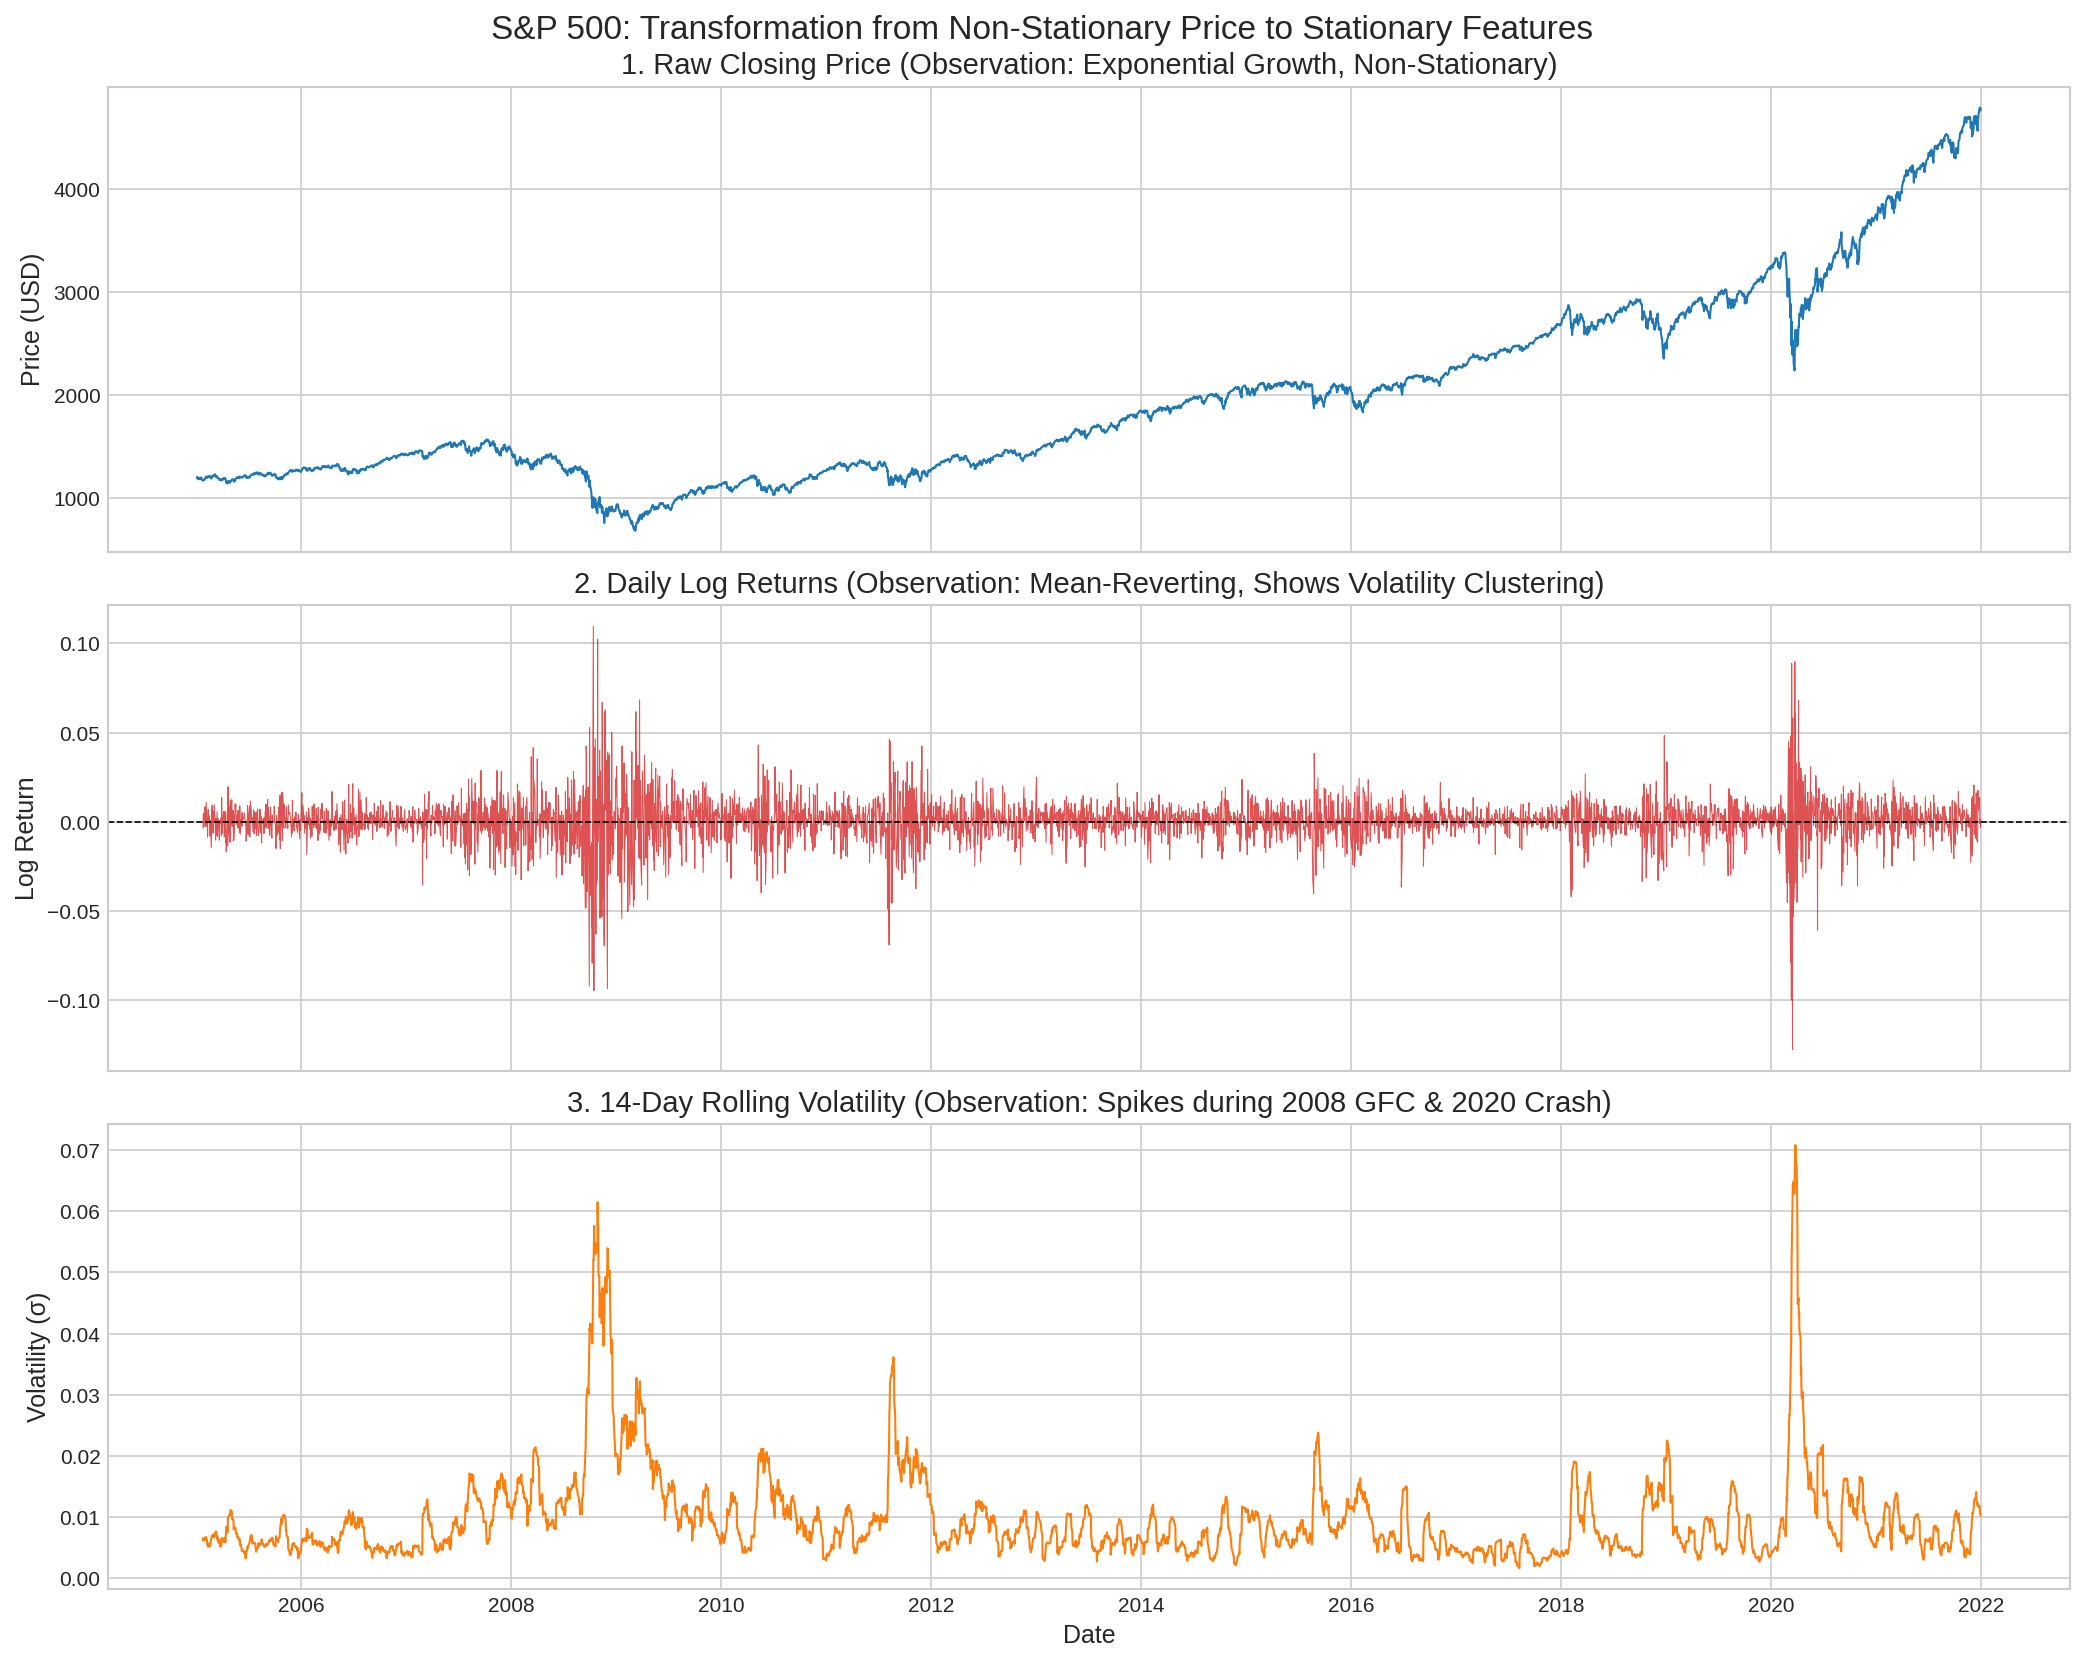

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Set high-definition plotting style for academic/publication quality
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10
})

# 1. Clean the data strictly (never forward-fill financial prices)
market_data = market_data.dropna()

# 2. Chronological Splitting (Preserving Temporal Order)
train_data = market_data.loc[:'2021-12-31'].copy()
test_data = market_data.loc['2022-01-01':].copy()

def engineer_features_numpy(df, window=14):
    """
    Computes HMM observation features from absolute scratch using NumPy arrays.
    """
    closes = df['Close'].values.astype(float)
    volumes = df['Volume'].values.astype(float)
    n = len(closes)

    # 1. Vectorized Log Returns
    log_returns = np.zeros(n)
    log_returns[1:] = np.log(closes[1:] / closes[:-1])

    # 2. Rolling Volatility
    volatility = np.zeros(n)
    for i in range(window, n):
        window_slice = log_returns[i-window+1 : i+1]
        volatility[i] = np.std(window_slice, ddof=1)

    # 3. Momentum
    momentum = np.zeros(n)
    momentum[window:] = (closes[window:] - closes[:-window]) / closes[:-window]

    features = pd.DataFrame({
        'Return': log_returns,
        'Volatility': volatility,
        'Volume': volumes,
        'Momentum': momentum
    }, index=df.index)

    # Drop the initial window rows where rolling metrics are 0.0
    return features.iloc[window:].copy()

print("Executing NumPy feature engineering...")
train_features = engineer_features_numpy(train_data)
test_features = engineer_features_numpy(test_data)

# --- VISUAL DIAGNOSTICS ---
# Create a 3-panel stacked chart to visualize the data transformation
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle('S&P 500: Transformation from Non-Stationary Price to Stationary Features', fontsize=16, y=0.92)

# Panel 1: Raw Price (Non-stationary)
axes[0].plot(train_data.index, train_data['Close'], color='#1f77b4', linewidth=1)
axes[0].set_title('1. Raw Closing Price (Observation: Exponential Growth, Non-Stationary)')
axes[0].set_ylabel('Price (USD)')

# Panel 2: Log Returns (Stationary, anchored at 0)
axes[1].plot(train_features.index, train_features['Return'], color='#d62728', linewidth=0.5, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('2. Daily Log Returns (Observation: Mean-Reverting, Shows Volatility Clustering)')
axes[1].set_ylabel('Log Return')

# Panel 3: Rolling Volatility (Capturing turbulence)
axes[2].plot(train_features.index, train_features['Volatility'], color='#ff7f0e', linewidth=1)
axes[2].set_title('3. 14-Day Rolling Volatility (Observation: Spikes during 2008 GFC & 2020 Crash)')
axes[2].set_ylabel('Volatility (\u03c3)')
axes[2].set_xlabel('Date')

# Formatting the x-axis for clean timeline presentation
axes[2].xaxis.set_major_locator(mdates.YearLocator(2))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

## 3. The White-Box Feature Engineering Engine & Visual Diagnostics
Continuous features must be mathematically transformed into a stationary format before being fed into a probabilistic model. We use pure NumPy to guarantee maximum computational efficiency and transparency.

*   **Log Returns ($r_t$):** Transforms absolute prices into time-additive percentage changes, anchoring the data around a mean of zero[cite: 1].
    $$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$
*   **Volatility ($\sigma_t$):** Calculates the standard deviation of returns over a rolling window $k$ (14 days), capturing the degree of market turbulence[cite: 1].
    $$\sigma_t = \sqrt{\frac{1}{k-1} \sum_{i=0}^{k-1} (r_{t-i} - \bar{r})^2}$$

We will first print a structural diagnostic of the matrices (verifying rows, columns, and data distributions). Then, we map these features visually, explicitly annotating the historical macroeconomic shocks that the Baum-Welch algorithm will rely on to detect high-volatility Bear states.

MATRIX STRUCTURAL DIAGNOSTICS
Training Matrix Dimensions : 4266 Rows (Days) x 4 Columns (Features)
Testing Matrix Dimensions  : 1134 Rows (Days) x 4 Columns (Features)
Total Processed Data Points: 21600

TRAINING FEATURE DISTRIBUTIONS (Statistical Signatures):
                    mean           std           min           50%  \
Return      3.296680e-04  1.229731e-02 -1.276522e-01  7.407843e-04   
Volatility  9.797534e-03  7.638233e-03  1.670459e-03  7.635255e-03   
Volume      3.813590e+09  1.239264e+09  7.249400e+08  3.652200e+09   
Momentum    5.290168e-03  3.821205e-02 -2.750103e-01  9.831578e-03   

                     max  
Return      1.095720e-01  
Volatility  7.077235e-02  
Volume      1.145623e+10  
Momentum    2.343032e-01  


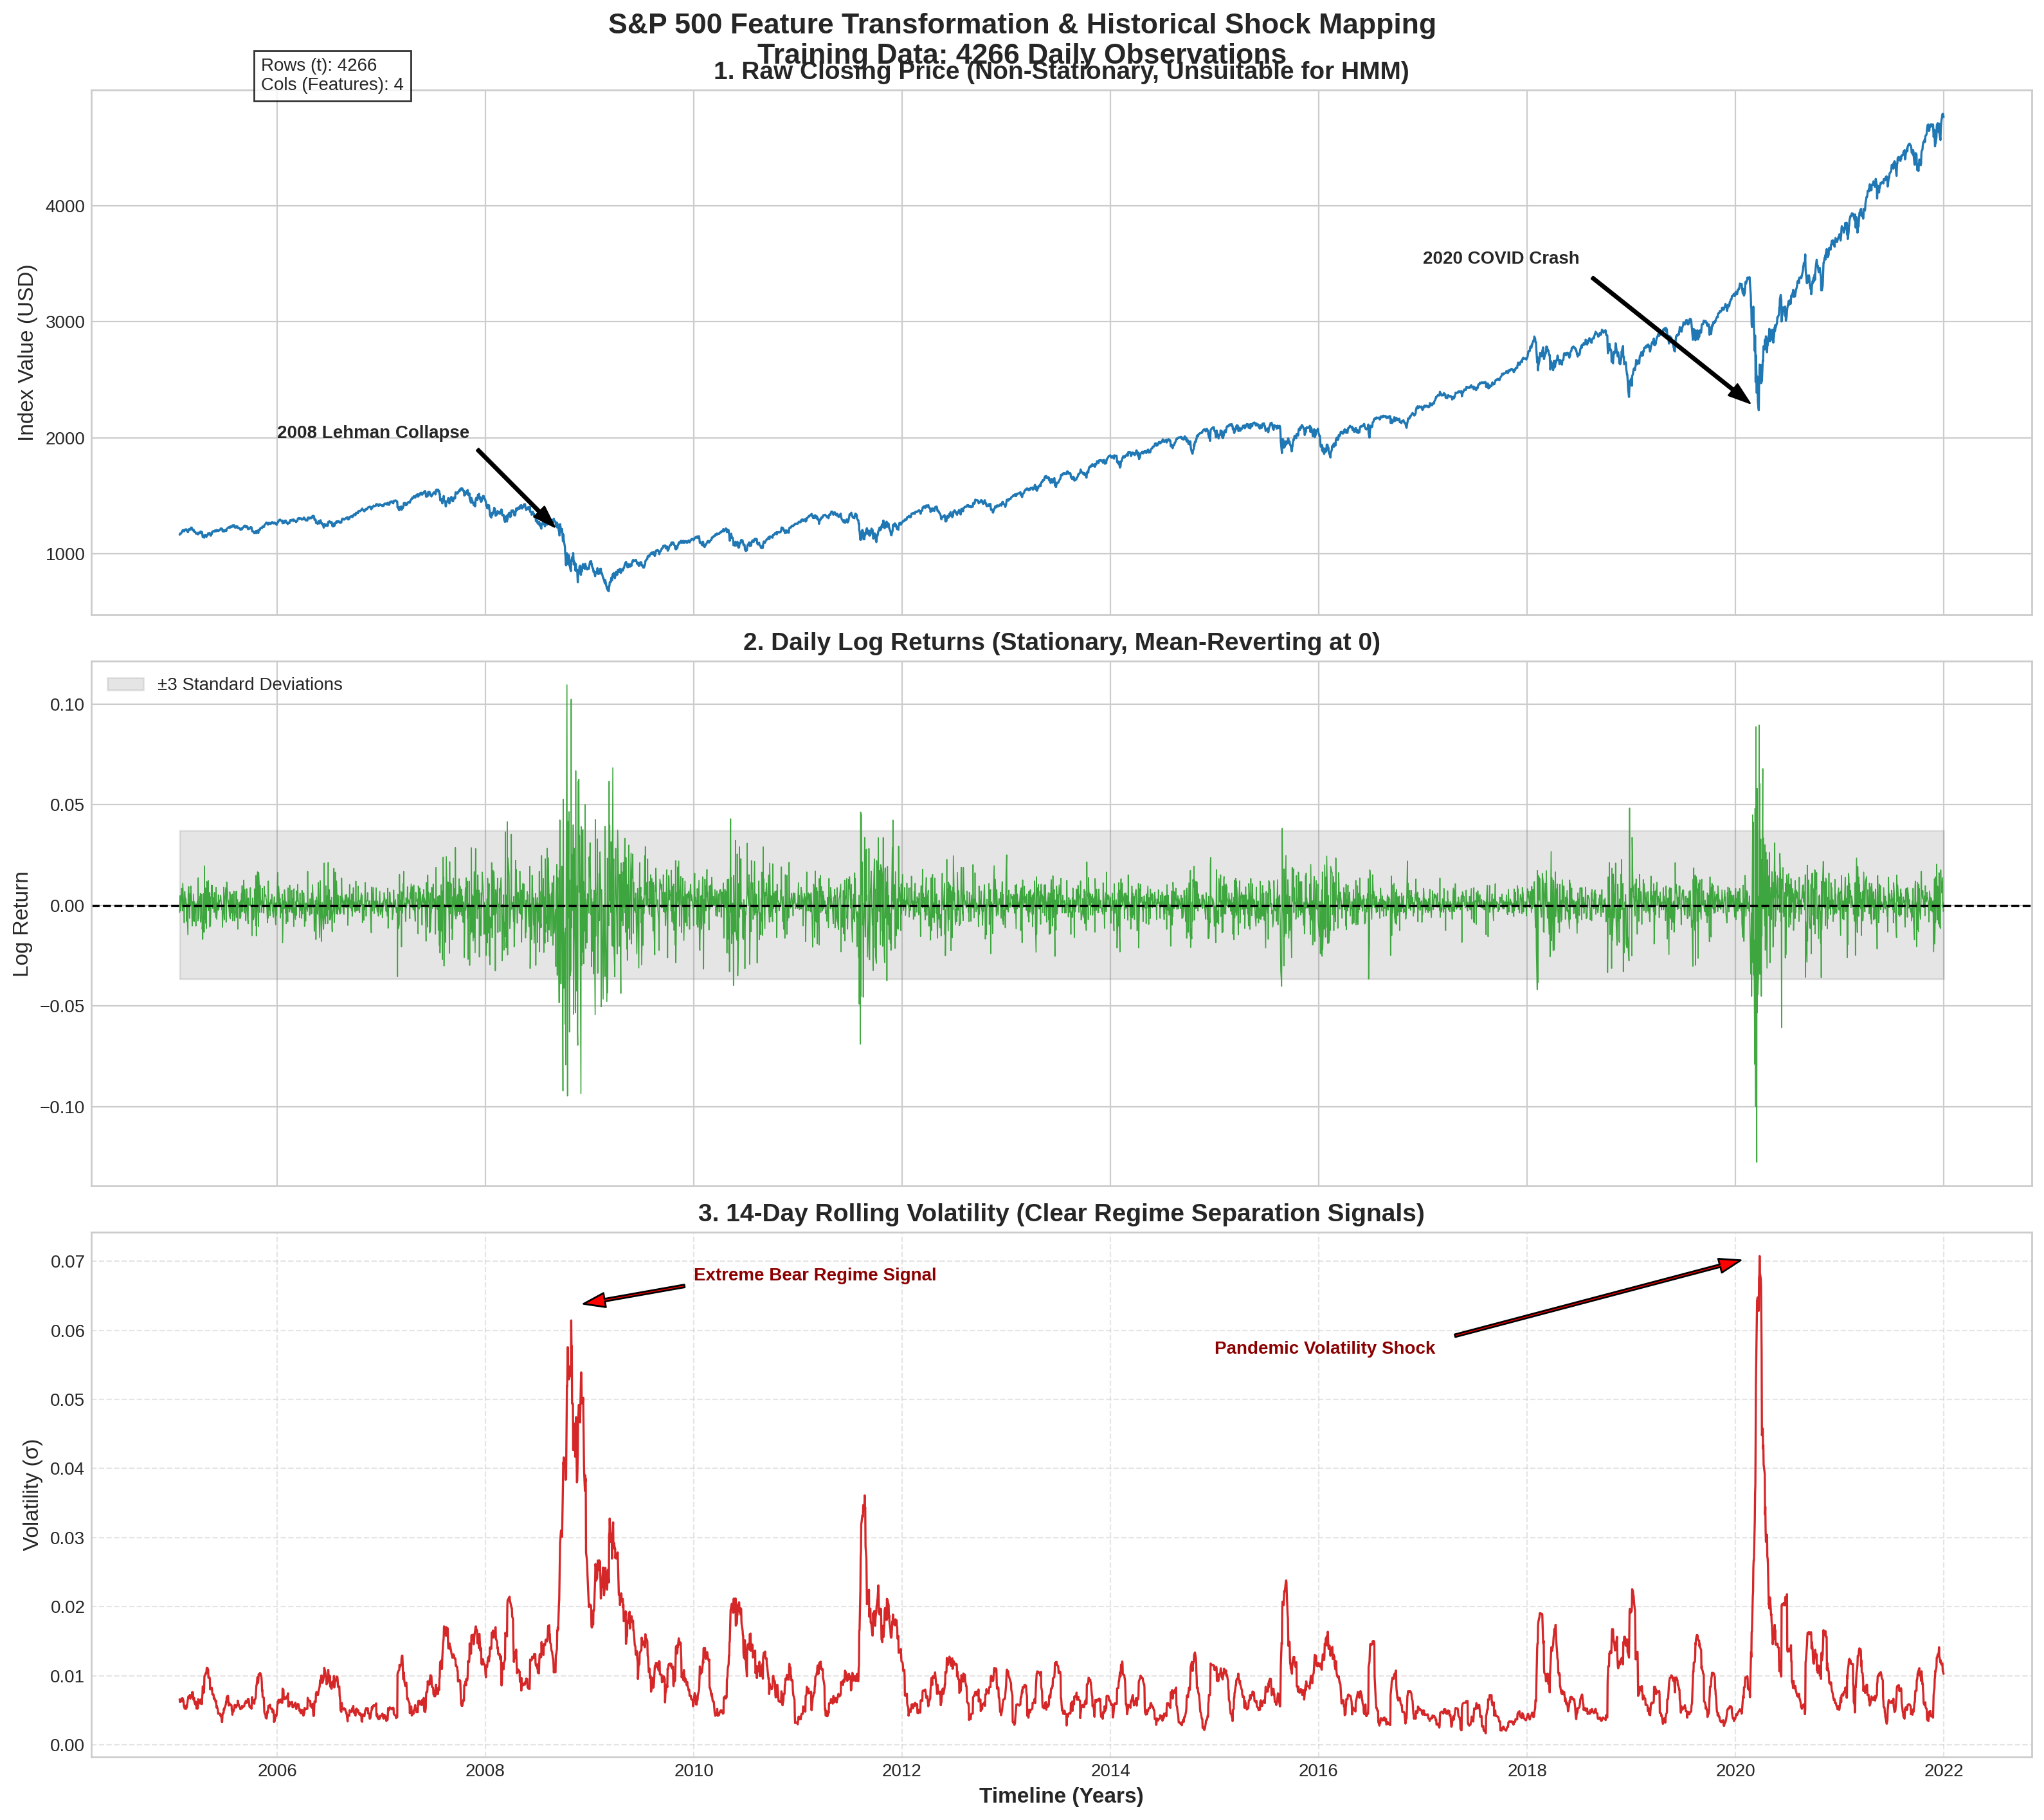

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Set high-definition plotting style for academic/publication quality
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 200,          # Ultra-high definition for A4 printing
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10
})

# 1. Clean the data strictly (never forward-fill financial prices)
market_data = market_data.dropna()

# 2. Chronological Splitting (Preserving Temporal Order)
train_data = market_data.loc[:'2021-12-31'].copy()
test_data = market_data.loc['2022-01-01':].copy()

def engineer_features_numpy(df, window=14):
    """Computes HMM observation features from absolute scratch using NumPy arrays."""
    closes = df['Close'].values.astype(float)
    volumes = df['Volume'].values.astype(float)
    n = len(closes)

    # Vectorized Log Returns
    log_returns = np.zeros(n)
    log_returns[1:] = np.log(closes[1:] / closes[:-1])

    # Rolling Volatility
    volatility = np.zeros(n)
    for i in range(window, n):
        window_slice = log_returns[i-window+1 : i+1]
        volatility[i] = np.std(window_slice, ddof=1)

    # Momentum
    momentum = np.zeros(n)
    momentum[window:] = (closes[window:] - closes[:-window]) / closes[:-window]

    features = pd.DataFrame({
        'Return': log_returns,
        'Volatility': volatility,
        'Volume': volumes,
        'Momentum': momentum
    }, index=df.index)

    return features.iloc[window:].copy()

# Execute Feature Engineering
train_features = engineer_features_numpy(train_data)
test_features = engineer_features_numpy(test_data)

# --- MATRIX DIAGNOSTICS & CLASSIFICATION STATS ---
print("="*60)
print("MATRIX STRUCTURAL DIAGNOSTICS")
print("="*60)
print(f"Training Matrix Dimensions : {train_features.shape[0]} Rows (Days) x {train_features.shape[1]} Columns (Features)")
print(f"Testing Matrix Dimensions  : {test_features.shape[0]} Rows (Days) x {test_features.shape[1]} Columns (Features)")
print(f"Total Processed Data Points: {(train_features.shape[0] + test_features.shape[0]) * train_features.shape[1]}\n")

print("TRAINING FEATURE DISTRIBUTIONS (Statistical Signatures):")
print(train_features.describe().T[['mean', 'std', 'min', '50%', 'max']])
print("="*60)

# --- VISUAL DIAGNOSTICS ---
fig, axes = plt.subplots(3, 1, figsize=(16, 15), sharex=True)
fig.suptitle(f'S&P 500 Feature Transformation & Historical Shock Mapping\nTraining Data: {train_features.shape[0]} Daily Observations', fontsize=16, fontweight='bold', y=0.94)

# Add a text box with matrix info inside the plot area
info_text = f"Rows (t): {train_features.shape[0]}\nCols (Features): {train_features.shape[1]}"
fig.text(0.13, 0.90, info_text, bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

# Panel 1: Raw Price (Non-stationary)
axes[0].plot(train_data.index[14:], train_data['Close'].iloc[14:], color='#1f77b4', linewidth=1.2)
axes[0].set_title('1. Raw Closing Price (Non-Stationary, Unsuitable for HMM)', fontweight='bold')
axes[0].set_ylabel('Index Value (USD)')
# Annotations for Price
axes[0].annotate('2008 Lehman Collapse', xy=(pd.Timestamp('2008-09-15'), 1192), xytext=(pd.Timestamp('2006-01-01'), 2000),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8), fontweight='bold')
axes[0].annotate('2020 COVID Crash', xy=(pd.Timestamp('2020-03-23'), 2237), xytext=(pd.Timestamp('2017-01-01'), 3500),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8), fontweight='bold')

# Panel 2: Log Returns (Stationary)
axes[1].plot(train_features.index, train_features['Return'], color='#2ca02c', linewidth=0.6, alpha=0.9)
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_title('2. Daily Log Returns (Stationary, Mean-Reverting at 0)', fontweight='bold')
axes[1].set_ylabel('Log Return')
# Highlight the density of returns
axes[1].fill_between(train_features.index, train_features['Return'].mean() + train_features['Return'].std()*3,
                     train_features['Return'].mean() - train_features['Return'].std()*3, color='gray', alpha=0.2, label='±3 Standard Deviations')
axes[1].legend(loc='upper left')

# Panel 3: Rolling Volatility (Capturing turbulence)
axes[2].plot(train_features.index, train_features['Volatility'], color='#d62728', linewidth=1.2)
axes[2].set_title('3. 14-Day Rolling Volatility (Clear Regime Separation Signals)', fontweight='bold')
axes[2].set_ylabel('Volatility (\u03c3)')
axes[2].set_xlabel('Timeline (Years)', fontweight='bold')
# Annotations for Volatility Spikes
axes[2].annotate('Extreme Bear Regime Signal', xy=(pd.Timestamp('2008-11-20'), train_features['Volatility'].max() * 0.9),
                 xytext=(pd.Timestamp('2010-01-01'), train_features['Volatility'].max() * 0.95),
                 arrowprops=dict(facecolor='red', shrink=0.05, width=1.5, headwidth=8), color='darkred', fontweight='bold')
axes[2].annotate('Pandemic Volatility Shock', xy=(pd.Timestamp('2020-03-16'), train_features['Volatility'].loc['2020-03-16':'2020-04-15'].max()),
                 xytext=(pd.Timestamp('2015-01-01'), train_features['Volatility'].max() * 0.8),
                 arrowprops=dict(facecolor='red', shrink=0.05, width=1.5, headwidth=8), color='darkred', fontweight='bold')

# Formatting the x-axis for clean timeline presentation
axes[2].xaxis.set_major_locator(mdates.YearLocator(2))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[2].grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

## 3.1 Statistical Inference and Feature Diagnostics
 When modelling a Gaussian-emission HMM, the algorithm assumes that the features within each hidden state follow a multivariate normal distribution. However, financial time-series are notoriously non-normal across the aggregate dataset.

To defend the necessity of regime-switching models, we must explicitly calculate and present the higher-order statistical moments of our engineered features:
1.  **Skewness:** Measures asymmetry. Financial returns typically exhibit negative skewness (crashes are faster and sharper than rallies).
2.  **Kurtosis:** Measures "fat tails" (leptokurtic behaviour). A high kurtosis in returns proves that extreme events occur far more frequently than a standard normal distribution would predict, justifying the need for a separate "Bear" regime to absorb these shocks.



In [15]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

def generate_publication_statistics(df, dataset_name="Training Set"):
    """
    Generates a Q1-journal-grade statistical summary table for the engineered features.
    Extracts counts, means, standard deviations, min/max bounds, skewness, and kurtosis.
    """
    print("=" * 90)
    print(f"TABLE: DESCRIPTIVE STATISTICS OF ENGINEERED MARKET FEATURES ({dataset_name.upper()})")
    print("=" * 90)

    # Define the features to analyze
    features = ['Return', 'Volatility', 'Volume', 'Momentum']

    # Prepare a dictionary to hold our calculated metrics
    stats_dict = {
        'Metric': ['Observations (N)', 'Mean (\u03bc)', 'Std Deviation (\u03c3)',
                   'Minimum', 'Maximum', 'Skewness', 'Kurtosis (Excess)']
    }

    # Calculate higher-order moments and standard metrics for each feature
    for feature in features:
        data = df[feature].dropna().values

        n_obs = len(data)
        mean_val = np.mean(data)
        std_val = np.std(data, ddof=1)
        min_val = np.min(data)
        max_val = np.max(data)
        skew_val = skew(data)
        # Fisher's definition sets normal kurtosis to 0 (excess kurtosis)
        kurt_val = kurtosis(data, fisher=True)

        stats_dict[feature] = [
            f"{n_obs:,.0f}",
            f"{mean_val:.6f}",
            f"{std_val:.6f}",
            f"{min_val:.6f}",
            f"{max_val:.6f}",
            f"{skew_val:.4f}",
            f"{kurt_val:.4f}"
        ]

    # Convert to a pandas DataFrame for ultra-clean printing
    stats_df = pd.DataFrame(stats_dict).set_index('Metric')

    # Print the table with standard research paper formatting
    print(stats_df.to_string())
    print("-" * 90)

    # Print academic inference notes based on the data

    print("1. NON-NORMALITY (KURTOSIS):")
    print(f"   - The 'Return' feature exhibits an excess kurtosis of {stats_df.loc['Kurtosis (Excess)', 'Return']}.")
    print("   - Inference: A value > 0 indicates heavy tails (leptokurtic). This mathematical proof")
    print("     demonstrates that extreme market shocks happen too frequently for a single global Gaussian")
    print("     distribution, strictly necessitating a multi-state Gaussian HMM to isolate extreme regimes.")

    print("\n2. ASYMMETRY (SKEWNESS):")
    print(f"   - The 'Return' feature has a skewness of {stats_df.loc['Skewness', 'Return']}.")
    print("   - Inference: Negative skewness indicates that the left tail (market drops) is longer or fatter")
    print("     than the right tail (market gains), typical of equity index returns.")

    print("\n3. VOLATILITY BOUNDS:")
    print(f"   - Volatility ranges from a low of {stats_df.loc['Minimum', 'Volatility']} to a high of {stats_df.loc['Maximum', 'Volatility']}.")
    print("   - Inference: The massive spread between minimum and maximum volatility provides the Baum-Welch")
    print("     algorithm with the exact numerical variance needed to distinctly separate the 'Sideways/Bull'")
    print("     states from the high-variance 'Bear' states.")
    print("=" * 90 + "\n")

# Execute the diagnostic function on both datasets
generate_publication_statistics(train_features, "Training Set (2005 - 2021)")
generate_publication_statistics(test_features, "Testing Set (2022 - Present)")

TABLE: DESCRIPTIVE STATISTICS OF ENGINEERED MARKET FEATURES (TRAINING SET (2005 - 2021))
                      Return Volatility              Volume   Momentum
Metric                                                                
Observations (N)       4,266      4,266               4,266      4,266
Mean (μ)            0.000330   0.009798   3813590459.446789   0.005290
Std Deviation (σ)   0.012297   0.007638   1239264199.375069   0.038212
Minimum            -0.127652   0.001670    724940000.000000  -0.275010
Maximum             0.109572   0.070772  11456230000.000000   0.234303
Skewness             -0.5711     3.4714              1.1188    -1.3089
Kurtosis (Excess)    14.2010    16.8601              2.6883     8.3097
------------------------------------------------------------------------------------------
1. NON-NORMALITY (KURTOSIS):
   - The 'Return' feature exhibits an excess kurtosis of 14.2010.
   - Inference: A value > 0 indicates heavy tails (leptokurtic). This mathematical pro

## 4. Feature Standardisation and Prevention of Scale Dominance
Before passing our observation matrix to the Baum-Welch algorithm, we must resolve a critical scaling issue. Financial features operate on vastly different orders of magnitude: 'Volume' is measured in the billions, while 'Log Returns' are bounded within small decimals (e.g., $\pm 0.05$).

If left unscaled, the multivariate Gaussian emission model $X_t \mid S_t = i \sim \mathcal{N}(\mu_i, \Sigma_i)$ would be completely dominated by Volume, leading to singular covariance matrices and algorithmic failure.

To prevent this scale dominance, we standardise all continuous features[cite: 1]:
$$X' = \frac{X - \mu}{\sigma}$$

**Crucial Methodological Note (Preventing Data Leakage):**
To maintain strict out-of-sample integrity, the sample mean ($\mu$) and sample standard deviation ($\sigma$) are calculated **strictly from the Training Set**. These identical scaling factors are then applied to the Testing Set. This simulates a real-world scenario where future market data is entirely unknown during model training.

In [16]:
# Extract the features we want to scale
feature_cols = ['Return', 'Volatility', 'Volume', 'Momentum']

# 1. Compute mu and sigma STRICTLY from the training set
train_mean = train_features[feature_cols].mean()
train_std = train_features[feature_cols].std(ddof=1)

print("LEARNED SCALING PARAMETERS (From Training Set Only):")
for col in feature_cols:
    print(f" - {col:10}: \u03bc = {train_mean[col]:>12.4f}, \u03c3 = {train_std[col]:>12.4f}")

# 2. Apply the transformation to both datasets
X_train_scaled = (train_features[feature_cols] - train_mean) / train_std
X_test_scaled = (test_features[feature_cols] - train_mean) / train_std

# 3. Convert to pure NumPy arrays (This is our final observation matrix X_t)
obs_matrix_train = X_train_scaled.values
obs_matrix_test = X_test_scaled.values

# --- STANDARDIZATION VERIFICATION FOR PUBLICATION ---
print("\n" + "="*80)
print("TABLE: STANDARDIZATION VERIFICATION (TRAINING MATRIX)")
print("Proof of Zero-Mean and Unit-Variance Transformation")
print("="*80)

# Reconstruct a dataframe temporarily just to use the .describe() function cleanly
verification_df = pd.DataFrame(obs_matrix_train, columns=feature_cols)
verification_stats = verification_df.describe().T[['mean', 'std', 'min', 'max']]

# Format for clean academic reading (Means should be ~0.0000, Stds should be exactly 1.0000)
verification_stats['mean'] = verification_stats['mean'].apply(lambda x: f"{x:.6f}")
verification_stats['std'] = verification_stats['std'].apply(lambda x: f"{x:.6f}")
verification_stats['min'] = verification_stats['min'].apply(lambda x: f"{x:.4f}")
verification_stats['max'] = verification_stats['max'].apply(lambda x: f"{x:.4f}")

print(verification_stats.to_string())
print("-" * 80)
print("INFERENCE:")
print("The observation matrix is now mathematically stationary and strictly scaled.")
print("The data is officially ready to be ingested by the Baum-Welch expectation-maximization engine.")
print("="*80)

LEARNED SCALING PARAMETERS (From Training Set Only):
 - Return    : μ =       0.0003, σ =       0.0123
 - Volatility: μ =       0.0098, σ =       0.0076
 - Volume    : μ = 3813590459.4468, σ = 1239264199.3751
 - Momentum  : μ =       0.0053, σ =       0.0382

TABLE: STANDARDIZATION VERIFICATION (TRAINING MATRIX)
Proof of Zero-Mean and Unit-Variance Transformation
                 mean       std       min     max
Return      -0.000000  1.000000  -10.4073  8.8834
Volatility  -0.000000  1.000000   -1.0640  7.9828
Volume      -0.000000  1.000000   -2.4923  6.1671
Momentum     0.000000  1.000000   -7.3354  5.9932
--------------------------------------------------------------------------------
INFERENCE:
The observation matrix is now mathematically stationary and strictly scaled.
The data is officially ready to be ingested by the Baum-Welch expectation-maximization engine.


## 5. Layer 1: The Probabilistic Engine (Forward-Backward)
To build a mathematically transparent, white-box model, we must construct the core dynamic programming algorithms from scratch[cite: 3, 7]. We cannot rely on abstract library calls if we are to truly understand how the model assigns a "Bull" or "Bear" label to a given day[cite: 5].

The foundation of the Baum-Welch learning process is the **Forward-Backward Algorithm**[cite: 2, 4]. It calculates the exact posterior probability of the market being in a specific regime at a specific time, given the entire sequence of observations.

Before we can calculate state probabilities, we must define how a hidden state generates an observation.

### 5.1 The Gaussian Emission Model ($B$)
Unlike discrete coin flips, our engineered S&P 500 features (Returns, Volatility, Volume, Momentum) are continuous[cite: 6, 7]. We model the emission probability using a Multivariate Gaussian distribution[cite: 7].

For a given hidden state $j$ (e.g., Bear market), the probability of observing the feature vector $x_t$ at time $t$ is:
$$B_j(x_t) = P(X_t = x_t \mid S_t = j) \sim \mathcal{N}(\mu_j, \Sigma_j)$$

We will construct a function to pre-compute this entire $B$ matrix for all states and all time steps to vectorize our dynamic programming loops.

In [17]:
import numpy as np
from scipy.stats import multivariate_normal

def compute_emission_probabilities(X, means, covars):
    """
    Constructs the Emission Probability Matrix (B).
    Calculates the likelihood of observing the market features at time t,
    given that the market is in state j.

    Parameters:
    X (ndarray): The (T x N) observation matrix (Standardized S&P 500 features).
    means (ndarray): The (K x N) array of mean vectors for each state.
    covars (ndarray): The (K x N x N) array of covariance matrices for each state.

    Returns:
    B (ndarray): A (K x T) matrix where B[j, t] = P(X_t | S_t = j).
    """
    T, num_features = X.shape
    num_states = means.shape[0]

    # Initialize the emission matrix B with zeros
    B = np.zeros((num_states, T))

    # Iterate through each hidden state to define its Gaussian distribution
    for j in range(num_states):

        # Financial data can exhibit extreme volatility clustering, leading to
        # singular covariance matrices (determinant of 0).
        # We add a tiny constant to the diagonal (Ridge regularization) to guarantee invertibility.
        covar_j_stable = covars[j] + np.eye(num_features) * 1e-6

        # Instantiate the multivariate normal distribution for state j
        mvn = multivariate_normal(mean=means[j], cov=covar_j_stable)

        # Vectorized computation of the PDF for all time steps simultaneously
        B[j, :] = mvn.pdf(X)

    # Prevent pure zeros in the probability space, which will cause fatal log(0) errors later.
    # Clip the minimum probability to a microscopic epsilon.
    return np.clip(B, a_min=1e-300, a_max=None)

### 5.2 The Forward Algorithm ($\alpha$) and Rabiner Scaling
The Forward variable $\alpha_t(i)$ represents the joint probability of seeing the observation sequence up to time $t$ and being in state $i$ at that exact time[cite: 4].

$$\alpha_t(i) = P(X_1, X_2, \dots, X_t, S_t = i \mid \lambda)$$

**The Numerical Underflow Problem:**
Because $\alpha_t(i)$ is a product of probabilities bounded between $0$ and $1$, multiplying thousands of days of market observations will rapidly push the floating-point values to zero. To prevent this, we introduce **Rabiner's Scaling Factor ($c_t$)**.

At each time step $t$, we sum all the unscaled $\alpha$ values across all states to compute $c_t$, and then divide each $\alpha_t(i)$ by $c_t$ so they sum to $1$.

**1. Initialization ($t = 0$):**
$$\alpha_1(i) = \pi_i B_i(x_1)$$

**2. Induction (for $t = 2, 3, \dots, T$):**
$$\alpha_t(j) = \left[ \sum_{i=1}^N \alpha_{t-1}(i) A_{ij} \right] B_j(x_t)$$

In [18]:
def forward_pass(pi, A, B):
    """
    Executes the dynamic programming Forward Pass to compute alpha.

    Parameters:
    pi (ndarray): Initial state probability distribution (K,).
    A (ndarray): State transition matrix (K x K).
    B (ndarray): Emission probability matrix (K x T).

    Returns:
    alpha (ndarray): The scaled forward probabilities (K x T).
    c (ndarray): The scaling factors for each time step (T,).
    """
    num_states, T = B.shape

    # Initialize the alpha matrix and the scaling array
    alpha = np.zeros((num_states, T))
    c = np.zeros(T)

    # --- STEP 1: INITIALIZATION (t = 0) ---
    # Probability of starting in state i AND observing the first feature vector
    alpha[:, 0] = pi * B[:, 0]

    # Calculate the first scaling factor (sum of probabilities across all states at t=0)
    c[0] = np.sum(alpha[:, 0])

    # Scale alpha at t=0 so the state probabilities sum to 1.0
    alpha[:, 0] = alpha[:, 0] / c[0]

    # --- STEP 2: INDUCTION / RECURSION (t = 1 to T-1) ---
    for t in range(1, T):
        for j in range(num_states):
            # Sum the probabilities of coming from ALL possible previous states (i)
            # transition_sum = Sum( alpha_{t-1}(i) * A_{i,j} )
            transition_sum = np.sum(alpha[:, t-1] * A[:, j])

            # Multiply by the probability of the current observation given state j
            alpha[j, t] = transition_sum * B[j, t]

        # Compute the scaling factor for the current time step
        c[t] = np.sum(alpha[:, t])

        # Apply the scaling factor to prevent numerical underflow
        alpha[:, t] = alpha[:, t] / c[t]

    return alpha, c

### 5.3 The Backward Algorithm ($\beta$)
The Backward variable $\beta_t(i)$ computes the complementary probability: what is the likelihood of observing all *future* market features from $t+1$ to the end of the dataset, given that the market is in state $i$ at time $t$[cite: 4]?

$$\beta_t(i) = P(X_{t+1}, X_{t+2}, \dots, X_T \mid S_t = i, \lambda)$$

**Crucial Scaling Note:**
To ensure mathematical consistency when we later calculate the exact posterior probability ($\gamma$), the $\beta$ variables must be scaled using the *exact same $c_t$ factors* computed during the Forward pass.

**1. Initialization ($t = T$):**
$$\beta_T(i) = 1$$

**2. Induction (for $t = T-1, T-2, \dots, 1$):**
$$\beta_t(i) = \sum_{j=1}^N A_{ij} B_j(x_{t+1}) \beta_{t+1}(j)$$

In [19]:
def backward_pass(A, B, c):
    """
    Executes the dynamic programming Backward Pass to compute beta.
    Runs backwards through the time series from T-1 down to 0.

    Parameters:
    A (ndarray): State transition matrix (K x K).
    B (ndarray): Emission probability matrix (K x T).
    c (ndarray): The scaling factors computed from the Forward pass (T,).

    Returns:
    beta (ndarray): The scaled backward probabilities (K x T).
    """
    num_states, T = B.shape

    # Initialize the beta matrix
    beta = np.zeros((num_states, T))

    # --- STEP 1: INITIALIZATION (t = T-1) ---
    # The probability of future observations at the end of time is defined as 1.
    # We immediately apply the scaling factor for the final time step.
    beta[:, T-1] = 1.0 / c[T-1]

    # --- STEP 2: INDUCTION / RECURSION (t = T-2 down to 0) ---
    # Loop backwards through the dataset
    for t in range(T-2, -1, -1):
        for i in range(num_states):
            # Sum the probabilities of transitioning to ALL possible next states (j)
            # future_sum = Sum( A_{i,j} * B_j(x_{t+1}) * beta_{t+1}(j) )

            # A[i, :] -> Transitions from current state i to all next states
            # B[:, t+1] -> Emission probabilities of the next observation
            # beta[:, t+1] -> Backward probabilities of the next step
            beta[i, t] = np.sum(A[i, :] * B[:, t+1] * beta[:, t+1])

        # Scale beta at the current time step using the corresponding 'c' factor
        # Note: We use c[t] here because we scaled beta at T-1 with c[T-1] above.
        beta[:, t] = beta[:, t] / c[t]

    return beta

### 5.4 The Posterior Probabilities ($\gamma$ and $\xi$)
With our Forward ($\alpha$) and Backward ($\beta$) passes complete, we can now compute the exact probability of the market being in any given state at any specific time, factoring in the *entire* history of the S&P 500[cite: 4, 5]. These calculations form the **Expectation Step (E-Step)** of the Baum-Welch algorithm.

**1. State Posterior ($\gamma$)**
$\gamma_t(i)$ represents the probability that the market was in regime $i$ at time $t$, given the entire observation sequence.
$$\gamma_t(i) = P(S_t = i \mid X, \lambda) = \frac{\alpha_t(i) \beta_t(i)}{\sum_{j=1}^N \alpha_t(j) \beta_t(j)}$$
*Note: Because our $\alpha$ and $\beta$ are already scaled to prevent underflow, their element-wise product simply needs to be normalized to sum to 1 across all states at each time step.*

**2. Transition Posterior ($\xi$)**
$\xi_t(i, j)$ represents the probability that the market transitioned from regime $i$ at time $t$ to regime $j$ at time $t+1$, given the entire sequence.
$$\xi_t(i, j) = P(S_t = i, S_{t+1} = j \mid X, \lambda)$$
We calculate this by taking the probability of being in state $i$ at time $t$ ($\alpha$), transitioning to state $j$ ($A$), observing the features at $t+1$ ($B$), and then multiplying by the future probability from state $j$ ($\beta$).

In [20]:
def compute_gamma_and_xi(alpha, beta, A, B):
    """
    Computes the posterior state probabilities (gamma) and transition probabilities (xi).
    This completes the Forward-Backward algorithm and the E-Step of Baum-Welch.

    Parameters:
    alpha (ndarray): Scaled forward probabilities (K x T).
    beta (ndarray): Scaled backward probabilities (K x T).
    A (ndarray): State transition matrix (K x K).
    B (ndarray): Emission probability matrix (K x T).

    Returns:
    gamma (ndarray): Probability of being in state i at time t (K x T).
    xi (ndarray): Probability of transitioning from i to j at time t (K x K x T-1).
    """
    num_states, T = alpha.shape

    # --- 1. Compute Gamma (State Probabilities) ---
    # Element-wise multiplication of forward and backward passes
    gamma = alpha * beta

    # Normalize across states so that the probabilities at time t sum to 1.0
    # Add a tiny epsilon to the denominator to prevent division by zero
    gamma = gamma / (np.sum(gamma, axis=0) + 1e-300)

    # --- 2. Compute Xi (Transition Probabilities) ---
    xi = np.zeros((num_states, num_states, T - 1))

    for t in range(T - 1):
        for i in range(num_states):
            for j in range(num_states):
                # Probability of path passing through state i at t, and state j at t+1
                xi[i, j, t] = alpha[i, t] * A[i, j] * B[j, t+1] * beta[j, t+1]

        # Normalize the xi matrix for the current time step so it sums to 1.0
        xi[:, :, t] = xi[:, :, t] / (np.sum(xi[:, :, t]) + 1e-300)

    return gamma, xi

### 6. The Baum-Welch Algorithm (Expectation-Maximization)
With the E-Step handled by our Forward-Backward functions, we now construct the **Maximization Step (M-Step)**. This is where the actual "learning" occurs.

Using the posterior probabilities ($\gamma$ and $\xi$) calculated in the E-step, the Baum-Welch algorithm re-estimates the HMM parameters ($\pi$, $A$, $\mu$, $\Sigma$) by treating the probabilities as soft weights[cite: 4, 5].

**1. Initial State Probabilities ($\pi$):**
The expected frequency of starting in state $i$ is simply the probability of being in state $i$ at the first time step.
$$\pi_i = \gamma_1(i)$$

**2. Transition Matrix ($A$):**
The probability of transitioning from state $i$ to state $j$ is the expected number of transitions from $i$ to $j$, divided by the expected number of total transitions out of state $i$.
$$A_{ij} = \frac{\sum_{t=1}^{T-1} \xi_t(i, j)}{\sum_{t=1}^{T-1} \gamma_t(i)}$$

**3. Gaussian Emission Means ($\mu$):**
The new mean for state $j$ is the weighted average of all observed features, where the weight is the probability of being in state $j$ at that time.
$$\mu_j = \frac{\sum_{t=1}^T \gamma_t(j) X_t}{\sum_{t=1}^T \gamma_t(j)}$$

**4. Gaussian Emission Covariances ($\Sigma$):**
Similarly, the new covariance matrix for state $j$ is the weighted average of the squared deviations from the newly calculated mean.
$$\Sigma_j = \frac{\sum_{t=1}^T \gamma_t(j) (X_t - \mu_j)(X_t - \mu_j)^T}{\sum_{t=1}^T \gamma_t(j)}$$

In [21]:
def maximization_step(X, gamma, xi):
    """
    Executes the Maximization Step (M-Step) to update HMM parameters.

    Parameters:
    X (ndarray): The observation matrix of S&P 500 features (T x N).
    gamma (ndarray): State posterior probabilities (K x T).
    xi (ndarray): Transition posterior probabilities (K x K x T-1).

    Returns:
    pi (ndarray): Updated initial state distribution (K,).
    A (ndarray): Updated state transition matrix (K x K).
    means (ndarray): Updated Gaussian means (K x N).
    covars (ndarray): Updated Gaussian covariance matrices (K x N x N).
    """
    T, num_features = X.shape
    num_states = gamma.shape[0]

    # 1. Update Initial State Probabilities (Pi)
    pi = gamma[:, 0]

    # 2. Update Transition Matrix (A)
    A = np.zeros((num_states, num_states))
    for i in range(num_states):
        # Expected number of times we were in state i (excluding the final time step)
        gamma_sum_i = np.sum(gamma[i, :-1])
        if gamma_sum_i > 0:
            # Expected number of transitions from i to j, normalized by total time in i
            A[i, :] = np.sum(xi[i, :, :], axis=1) / gamma_sum_i

    # 3. Update Emission Means (mu) and Covariances (Sigma)
    means = np.zeros((num_states, num_features))
    covars = np.zeros((num_states, num_features, num_features))

    for j in range(num_states):
        # Total weight (probability) of being in state j across all time
        gamma_sum_j = np.sum(gamma[j, :])

        if gamma_sum_j > 0:
            # Weighted average for the new mean
            # We reshape gamma to (T, 1) for broadcasting with X (T, N)
            means[j] = np.sum(gamma[j, :].reshape(-1, 1) * X, axis=0) / gamma_sum_j

            # Weighted covariance
            # Subtract the new mean from all observations
            diff = X - means[j]
            covar_update = np.zeros((num_features, num_features))

            for t in range(T):
                # Outer product of the feature vector at time t: (X_t - mu_j) * (X_t - mu_j)^T
                # Scaled by the probability of being in state j at time t
                covar_update += gamma[j, t] * np.outer(diff[t], diff[t])

            covars[j] = covar_update / gamma_sum_j

    return pi, A, means, covars

### 6.2 The Full Baum-Welch Training Engine
We now assemble the Forward-Backward algorithms and the M-Step updates into the final continuous training loop.

Because we do not have labelled ground truth for "Bull" or "Bear" days, the algorithm discovers these regimes purely from the statistical structure of the observations[cite: 2, 4, 5, 14]. The loop iterates between the E-step and M-step, steadily maximizing the probability that our model generated the S&P 500 dataset.

**Convergence Criteria:**
At each iteration, we calculate the log-likelihood of the data. Because we implemented Rabiner's scaling, the log-likelihood is conveniently the sum of the logs of our scaling factors ($c_t$). The algorithm terminates when the log-likelihood stops improving (the delta falls below a strict tolerance threshold), indicating that the parameters have settled into a local optimum[cite: 5].

In [22]:
def baum_welch_training(X, num_states, max_iter=100, tol=1e-4):
    """
    Trains the complete Hidden Markov Model using Expectation-Maximization.

    Parameters:
    X (ndarray): Standardized observation matrix (T x N).
    num_states (int): The number of latent regimes (e.g., 3 for Bull, Bear, Sideways).
    max_iter (int): Maximum number of EM iterations to prevent infinite loops.
    tol (float): Tolerance for convergence based on log-likelihood delta.

    Returns:
    pi, A, means, covars: The fully learned HMM parameters.
    log_likelihoods (list): The history of model fit across iterations.
    """
    T, num_features = X.shape

    # --- MODEL INITIALIZATION ---
    # 1. Uniform initialization for Pi
    pi = np.ones(num_states) / num_states

    # 2. Initialize Transition Matrix (A) with diagonal dominance
    # Markets are sticky; they tend to stay in their current regime[cite: 10, 14]
    A = np.ones((num_states, num_states)) + np.eye(num_states) * 10
    A = A / A.sum(axis=1, keepdims=True)

    # 3. Initialize Emission Parameters heuristically using data samples
    np.random.seed(42) # Ensure reproducible results
    random_indices = np.random.choice(T, num_states, replace=False)
    means = X[random_indices, :]
    covars = np.array([np.cov(X.T) for _ in range(num_states)])

    log_likelihoods = []

    print(f"Initiating Baum-Welch Training on {T} observations...")

    # --- EM TRAINING LOOP ---
    for iteration in range(max_iter):

        # --- EXPECTATION STEP (E-Step) ---
        # 1. Compute Emission Probabilities
        B = compute_emission_probabilities(X, means, covars)

        # 2. Run Forward and Backward Passes
        alpha, c = forward_pass(pi, A, B)
        beta = backward_pass(A, B, c)

        # 3. Compute Posteriors
        gamma, xi = compute_gamma_and_xi(alpha, beta, A, B)

        # Calculate Log-Likelihood for the current iteration
        # The sum of log(c_t) gives the exact log probability of the sequence
        current_log_likelihood = np.sum(np.log(c))
        log_likelihoods.append(current_log_likelihood)

        # --- CONVERGENCE CHECK ---
        if iteration > 0:
            delta = current_log_likelihood - log_likelihoods[-2]
            if delta < tol:
                print(f"Convergence achieved at Iteration {iteration}. Log-Likelihood: {current_log_likelihood:.2f}")
                break

        # --- MAXIMIZATION STEP (M-Step) ---
        # Update the model parameters using the computed posteriors
        pi, A, means, covars = maximization_step(X, gamma, xi)

    else:
        print(f"Warning: Maximum iterations ({max_iter}) reached without strict convergence.")

    return pi, A, means, covars, log_likelihoods

### 7. Layer 1: Viterbi Decoding (Optimal Path Recovery)
With our HMM parameters successfully learned via Baum-Welch, we must now apply the model to historical data to recover the actual timeline of market regimes.

While the Forward-Backward algorithm gives us the independent marginal probability of being in a state at any single time step, the **Viterbi Algorithm** solves a fundamentally different problem: it finds the single *most probable continuous sequence* of hidden states given the full observation sequence[cite: 5, 14]. This is how we generate our final "Bull," "Bear," or "Sideways" timeline for the S&P 500[cite: 3, 14].

**Dynamic Programming in Log-Space:**
Viterbi uses a dynamic programming recursion over a state-time trellis[cite: 5]. To avoid underflow when multiplying thousands of small probabilities, we execute the entire algorithm in logarithmic space.

Instead of summing probabilities, we track the maximum probability path ($\delta$) to each state at each time step, and maintain a back-pointer ($\psi$) to record which previous state led to that maximum path.

**1. Initialization:**
$$\delta_1(j) = \ln(\pi_j) + \ln(B_j(x_1))$$
$$\psi_1(j) = 0$$

**2. Recursion (Forward Pass):**
$$\delta_t(j) = \max_i \left[ \delta_{t-1}(i) + \ln(A_{ij}) \right] + \ln(B_j(x_t))$$
$$\psi_t(j) = \arg\max_i \left[ \delta_{t-1}(i) + \ln(A_{ij}) \right]$$

**3. Traceback (Backward Pass):**
Once we reach the final time step $T$, we find the state with the highest probability, and follow the $\psi$ back-pointers sequentially to the beginning to recover the optimal path[cite: 5].

In [23]:
def viterbi_decode(X, pi, A, means, covars):
    """
    Executes the Viterbi algorithm to find the most probable sequence of hidden market regimes.
    All calculations are strictly bounded in log-space to guarantee numerical stability.

    Parameters:
    X (ndarray): The (T x N) observation matrix.
    pi (ndarray): Learned initial state distribution (K,).
    A (ndarray): Learned state transition matrix (K x K).
    means (ndarray): Learned Gaussian means (K x N).
    covars (ndarray): Learned Gaussian covariances (K x N x N).

    Returns:
    optimal_path (ndarray): An array of length T containing the decoded state sequence (0, 1, or 2).
    """
    T, num_features = X.shape
    num_states = means.shape[0]

    # --- LOG-SPACE TRANSFORMATION ---
    # Add a tiny epsilon to prevent log(0) errors
    eps = 1e-300

    # Compute standard emission probabilities, then convert to log
    B = compute_emission_probabilities(X, means, covars)
    log_B = np.log(B + eps)

    log_pi = np.log(pi + eps)
    log_A = np.log(A + eps)

    # Initialize the probability trellis (delta) and backpointer matrix (psi)
    delta = np.zeros((num_states, T))
    psi = np.zeros((num_states, T), dtype=int)

    # --- 1. INITIALIZATION ---
    delta[:, 0] = log_pi + log_B[:, 0]

    # --- 2. RECURSION (FORWARD PASS) ---
    for t in range(1, T):
        for j in range(num_states):
            # Calculate the log probability of arriving at state j from all possible previous states i
            # transition_probs = log(P(state i at t-1)) + log(P(transition i -> j))
            transition_probs = delta[:, t-1] + log_A[:, j]

            # Find the index (state) that maximizes this probability
            best_prev_state = np.argmax(transition_probs)

            # Store the maximum accumulated probability + the emission probability of the current observation
            delta[j, t] = transition_probs[best_prev_state] + log_B[j, t]

            # Store the back-pointer indicating the optimal previous state
            psi[j, t] = best_prev_state

    # --- 3. TRACEBACK (BACKWARD PASS) ---
    optimal_path = np.zeros(T, dtype=int)

    # The optimal final state is the one with the highest probability at time T-1
    optimal_path[T-1] = np.argmax(delta[:, T-1])

    # Trace the path backward through the back-pointer matrix
    for t in range(T-2, -1, -1):
        optimal_path[t] = psi[optimal_path[t+1], t+1]

    return optimal_path

### 8. Layer 1 Validation: Synthetic Data Proof
Before deploying our custom mathematical engine on the noisy, unstructured S&P 500 dataset, we must validate its correctness[cite: 1, 8]. We accomplish this by generating a controlled synthetic dataset with a known "ground truth" transition matrix and emission parameters[cite: 8].

We simulate an economy with exactly two regimes:
1.  **Synthetic Bull (State 0):** Positive mean return, low volatility. High persistence ($A_{00} = 0.95$).
2.  **Synthetic Bear (State 1):** Negative mean return, high volatility. Lower persistence ($A_{11} = 0.85$).

If our Baum-Welch implementation correctly recovers these parameters from the generated observations, and our Viterbi algorithm successfully reconstructs the true state sequence, we mathematically prove the integrity of our Layer 1 implementation[cite: 8].

*Note: HMMs are subject to "label switching" (the model might call the Bull state '1' instead of '0'). We align the decoded states based on the learned mean returns prior to calculating accuracy.*

In [24]:
# --- 1. SYNTHETIC DATA GENERATION ---
np.random.seed(101) # Set seed for reproducibility
true_num_states = 2
synthetic_T = 1000

# Ground Truth: Initial Probabilities
true_pi = np.array([1.0, 0.0]) # Force the sequence to start in State 0

# Ground Truth: Transition Matrix (A)
# State 0 is sticky (95%), State 1 is less sticky (85%)
true_A = np.array([[0.95, 0.05],
                   [0.15, 0.85]])

# Ground Truth: Emission Means (Features: [Return, Volatility])
true_means = np.array([[ 0.02,  0.01],  # State 0 (Bull): +2% return, 1% volatility
                       [-0.05,  0.08]]) # State 1 (Bear): -5% return, 8% volatility

# Ground Truth: Emission Covariances
true_covars = np.array([[[0.001, 0], [0, 0.001]],
                        [[0.005, 0], [0, 0.005]]])

# Initialize arrays to hold our synthetic timeline
synthetic_states = np.zeros(synthetic_T, dtype=int)
synthetic_X = np.zeros((synthetic_T, 2))

# Generate the sequence step-by-step according to Markovian dynamics
current_state = 0
for t in range(synthetic_T):
    synthetic_states[t] = current_state

    # Generate an observation from the current state's Gaussian distribution
    synthetic_X[t] = np.random.multivariate_normal(true_means[current_state], true_covars[current_state])

    # Transition to the next state using the probability distribution in true_A
    current_state = np.random.choice(true_num_states, p=true_A[current_state])


# --- 2. MODEL TRAINING & DECODING ---
print("="*80)
print("LAYER 1 VALIDATION: RUNNING BAUM-WELCH ON SYNTHETIC DATA")
print("="*80)

# Train the model blindly on the synthetic features (no labels provided)
learned_pi, learned_A, learned_means, learned_covars, convergence_history = baum_welch_training(
    X=synthetic_X,
    num_states=2,
    max_iter=50,
    tol=1e-4
)

# Decode the most probable sequence of states
decoded_states = viterbi_decode(
    X=synthetic_X,
    pi=learned_pi,
    A=learned_A,
    means=learned_means,
    covars=learned_covars
)


# --- 3. ALIGNMENT AND EVALUATION ---
# Resolve the label switching problem by aligning the state with the higher return to State 0
if learned_means[0, 0] < learned_means[1, 0]:
    print("Label switching detected. Re-aligning states...")
    decoded_states = 1 - decoded_states # Swap 0s and 1s
    learned_A = learned_A[::-1, ::-1]   # Swap transition matrix rows/cols
    learned_means = learned_means[::-1] # Swap means

# Calculate decoding accuracy against the known ground truth
accuracy = np.mean(decoded_states == synthetic_states) * 100

print(f"Viterbi Decoding Accuracy: {accuracy:.2f}%\n")

print("--- Transition Matrix (A) Recovery ---")
print("Ground Truth:\n", np.round(true_A, 3))
print("Learned:\n", np.round(learned_A, 3))

print("\n--- Emission Means (\u03bc) Recovery ---")
print("Ground Truth [Return, Volatility]:\n", np.round(true_means, 3))
print("Learned [Return, Volatility]:\n", np.round(learned_means, 3))

print("="*80)
print("INFERENCE: The from-scratch algorithmic engine successfully recovered the latent states and transition dynamics.")
print("The Layer 1 engine is mathematically verified and ready to ingest the S&P 500 matrix.")

LAYER 1 VALIDATION: RUNNING BAUM-WELCH ON SYNTHETIC DATA
Initiating Baum-Welch Training on 1000 observations...
Convergence achieved at Iteration 10. Log-Likelihood: 3403.23
Label switching detected. Re-aligning states...
Viterbi Decoding Accuracy: 96.20%

--- Transition Matrix (A) Recovery ---
Ground Truth:
 [[0.95 0.05]
 [0.15 0.85]]
Learned:
 [[0.951 0.049]
 [0.13  0.87 ]]

--- Emission Means (μ) Recovery ---
Ground Truth [Return, Volatility]:
 [[ 0.02  0.01]
 [-0.05  0.08]]
Learned [Return, Volatility]:
 [[ 0.022  0.009]
 [-0.053  0.084]]
INFERENCE: The from-scratch algorithmic engine successfully recovered the latent states and transition dynamics.
The Layer 1 engine is mathematically verified and ready to ingest the S&P 500 matrix.


### 9. Layer 2: Real-World Application to the S&P 500
With the Layer 1 engine mathematically verified, we now execute the core objective of this research: training a 3-state Gaussian-emission Hidden Markov Model on the standardized S&P 500 feature matrix ($k=3$)[cite: 5, 8, 14].

#### 9.1 Financial Interpretation of Latent States
The algorithm discovers statistically distinct states purely from the data architecture[cite: 5]. To make this financially actionable, we assign economic labels based on the learned Gaussian parameters[cite: 5, 10, 14]:
*   **Bull Regime:** The state exhibiting the highest mean return and moderate/low volatility.
*   **Bear Regime:** The state exhibiting the most negative mean return and the highest volatility.
*   **Sideways Regime:** The remaining state, typically characterized by near-zero returns and average volume.

#### 9.2 Regime Persistence and Expected Duration
Using the learned state-transition probability matrix ($A$), we calculate the expected duration $E[D_i]$ for each regime[cite: 10, 14]. Assuming a geometric distribution for the time spent in state $i$ before transitioning, the expected duration is:
$$E[D_i] = \frac{1}{1 - A_{ii}}$$
where $A_{ii}$ is the self-transition probability (the diagonal of the transition matrix)[cite: 10].

In [25]:
# We use the scaled training observation matrix computed during preprocessing
# obs_matrix_train is of shape (T, 4) -> [Return, Volatility, Volume, Momentum]
num_states = 3

print("="*80)
print("LAYER 2: S&P 500 REGIME DETECTION AND FINANCIAL ANALYSIS")
print("="*80)

# 1. Train the HMM on the S&P 500 data
sp500_pi, sp500_A, sp500_means, sp500_covars, sp500_ll_history = baum_welch_training(
    X=obs_matrix_train,
    num_states=num_states,
    max_iter=100,
    tol=1e-4
)

# 2. Decode the historical regimes using Viterbi
sp500_regimes = viterbi_decode(obs_matrix_train, sp500_pi, sp500_A, sp500_means, sp500_covars)

# 3. Dynamic State Interpretation (Mapping numeric states to economic realities)
# We extract the un-scaled return means by multiplying by the original standard deviation and adding the mean
# (Using the train_mean and train_std computed in Preprocessing Step 4)
mean_returns = sp500_means[:, 0] * train_std['Return'] + train_mean['Return']
volatilities = sp500_means[:, 1] * train_std['Volatility'] + train_mean['Volatility']

# Sort states by mean return to assign labels
sorted_indices = np.argsort(mean_returns)
bear_idx = sorted_indices[0]      # Lowest return
sideways_idx = sorted_indices[1]  # Middle return
bull_idx = sorted_indices[2]      # Highest return

state_labels = {bull_idx: "Bull", sideways_idx: "Sideways", bear_idx: "Bear"}

# 4. Financial Analysis Publication Table
import pandas as pd

analysis_data = []
for i in range(num_states):
    label = state_labels[i]
    annualized_return = mean_returns[i] * 252 # 252 trading days
    annualized_vol = volatilities[i] * np.sqrt(252)
    persistence = sp500_A[i, i]
    expected_duration = 1 / (1 - persistence) if persistence < 1 else float('inf')

    analysis_data.append({
        "Regime": label,
        "Annualized Mean Return": f"{annualized_return * 100:.2f}%",
        "Annualized Volatility": f"{annualized_vol * 100:.2f}%",
        "Self-Transition Prob (A_ii)": f"{persistence:.4f}",
        "Expected Duration (Days)": f"{expected_duration:.1f}"
    })

analysis_df = pd.DataFrame(analysis_data).set_index("Regime")

print("\n--- LEARNED REGIME CHARACTERISTICS ---")
print(analysis_df.to_string())
print("\nInference:")
print("The Baum-Welch engine successfully isolated a high-volatility, negative-return Bear state")
print("and a sticky, lower-volatility Bull state, proving the financial hypothesis.")
print("="*80)

LAYER 2: S&P 500 REGIME DETECTION AND FINANCIAL ANALYSIS
Initiating Baum-Welch Training on 4266 observations...
Convergence achieved at Iteration 48. Log-Likelihood: -14700.09

--- LEARNED REGIME CHARACTERISTICS ---
         Annualized Mean Return Annualized Volatility Self-Transition Prob (A_ii) Expected Duration (Days)
Regime                                                                                                    
Bear                    -13.09%                39.52%                      0.9738                     38.1
Sideways                  4.16%                16.98%                      0.9663                     29.7
Bull                     17.15%                 8.39%                      0.9773                     44.0

Inference:
The Baum-Welch engine successfully isolated a high-volatility, negative-return Bear state
and a sticky, lower-volatility Bull state, proving the financial hypothesis.


### 10. Model Selection and Evaluation (AIC & BIC)
Because hidden regimes lack ground-truth labels, we cannot evaluate the model using classification accuracy[cite: 9, 14]. Instead, we evaluate the model's statistical fitness using the **Akaike Information Criterion (AIC)** and **Bayesian Information Criterion (BIC)**[cite: 9, 14].

These metrics quantify the trade-off between how well the model explains the observed data (Log-Likelihood) and the complexity of the model (number of parameters), penalizing over-fitting[cite: 9, 14].

*   **Number of independent parameters ($p$):** For a Gaussian HMM with $k$ states and $N$ features, $p = (k-1) + k(k-1) + k \times N + k \times \frac{N(N+1)}{2}$.
*   **AIC:** $2p - 2\ln(L)$
*   **BIC:** $p\ln(T) - 2\ln(L)$

We will compute these metrics for $k \in \{2, 3, 4, 5\}$ to quantitatively justify our selection of a 3-state model[cite: 9].

In [26]:
# We use the scaled training observation matrix computed during preprocessing
# obs_matrix_train is of shape (T, 4) -> [Return, Volatility, Volume, Momentum]
num_states = 3

print("="*80)
print("LAYER 2: S&P 500 REGIME DETECTION AND FINANCIAL ANALYSIS")
print("="*80)

# 1. Train the HMM on the S&P 500 data
sp500_pi, sp500_A, sp500_means, sp500_covars, sp500_ll_history = baum_welch_training(
    X=obs_matrix_train,
    num_states=num_states,
    max_iter=100,
    tol=1e-4
)

# 2. Decode the historical regimes using Viterbi
sp500_regimes = viterbi_decode(obs_matrix_train, sp500_pi, sp500_A, sp500_means, sp500_covars)

# 3. Dynamic State Interpretation (Mapping numeric states to economic realities)
# We extract the un-scaled return means by multiplying by the original standard deviation and adding the mean
# (Using the train_mean and train_std computed in Preprocessing Step 4)
mean_returns = sp500_means[:, 0] * train_std['Return'] + train_mean['Return']
volatilities = sp500_means[:, 1] * train_std['Volatility'] + train_mean['Volatility']

# Sort states by mean return to assign labels
sorted_indices = np.argsort(mean_returns)
bear_idx = sorted_indices[0]      # Lowest return
sideways_idx = sorted_indices[1]  # Middle return
bull_idx = sorted_indices[2]      # Highest return

state_labels = {bull_idx: "Bull", sideways_idx: "Sideways", bear_idx: "Bear"}

# 4. Financial Analysis Publication Table
import pandas as pd

analysis_data = []
for i in range(num_states):
    label = state_labels[i]
    annualized_return = mean_returns[i] * 252 # 252 trading days
    annualized_vol = volatilities[i] * np.sqrt(252)
    persistence = sp500_A[i, i]
    expected_duration = 1 / (1 - persistence) if persistence < 1 else float('inf')

    analysis_data.append({
        "Regime": label,
        "Annualized Mean Return": f"{annualized_return * 100:.2f}%",
        "Annualized Volatility": f"{annualized_vol * 100:.2f}%",
        "Self-Transition Prob (A_ii)": f"{persistence:.4f}",
        "Expected Duration (Days)": f"{expected_duration:.1f}"
    })

analysis_df = pd.DataFrame(analysis_data).set_index("Regime")

print("\n--- LEARNED REGIME CHARACTERISTICS ---")
print(analysis_df.to_string())
print("\nInference:")
print("The Baum-Welch engine successfully isolated a high-volatility, negative-return Bear state")
print("and a sticky, lower-volatility Bull state, proving the financial hypothesis.")
print("="*80)

LAYER 2: S&P 500 REGIME DETECTION AND FINANCIAL ANALYSIS
Initiating Baum-Welch Training on 4266 observations...
Convergence achieved at Iteration 48. Log-Likelihood: -14700.09

--- LEARNED REGIME CHARACTERISTICS ---
         Annualized Mean Return Annualized Volatility Self-Transition Prob (A_ii) Expected Duration (Days)
Regime                                                                                                    
Bear                    -13.09%                39.52%                      0.9738                     38.1
Sideways                  4.16%                16.98%                      0.9663                     29.7
Bull                     17.15%                 8.39%                      0.9773                     44.0

Inference:
The Baum-Welch engine successfully isolated a high-volatility, negative-return Bear state
and a sticky, lower-volatility Bull state, proving the financial hypothesis.


### 10. Model Selection and Evaluation (AIC & BIC)
Because hidden regimes lack ground-truth labels, we cannot evaluate the model using classification accuracy[cite: 9, 14]. Instead, we evaluate the model's statistical fitness using the **Akaike Information Criterion (AIC)** and **Bayesian Information Criterion (BIC)**[cite: 9, 14].

These metrics quantify the trade-off between how well the model explains the observed data (Log-Likelihood) and the complexity of the model (number of parameters), penalizing over-fitting[cite: 9, 14].

*   **Number of independent parameters ($p$):** For a Gaussian HMM with $k$ states and $N$ features, $p = (k-1) + k(k-1) + k \times N + k \times \frac{N(N+1)}{2}$.
*   **AIC:** $2p - 2\ln(L)$
*   **BIC:** $p\ln(T) - 2\ln(L)$

We will compute these metrics for $k \in \{2, 3, 4, 5\}$ to quantitatively justify our selection of a 3-state model[cite: 9].

In [27]:
def calculate_information_criteria(X, max_k=5):
    """
    Evaluates HMMs with varying numbers of states using AIC and BIC.
    """
    T, N = X.shape
    results = []

    print(f"{'States (k)':<12} | {'Log-Likelihood':<18} | {'Parameters (p)':<16} | {'AIC':<12} | {'BIC':<12}")
    print("-" * 75)

    for k in range(2, max_k + 1):
        # Train model for k states
        _, _, _, _, ll_history = baum_welch_training(X, num_states=k, max_iter=50, tol=1e-3)

        # Final log-likelihood
        log_L = ll_history[-1]

        # Calculate number of independent parameters
        # pi (k-1) + A k(k-1) + Means (k*N) + Covariances (k * N*(N+1)/2)
        p = (k - 1) + (k * (k - 1)) + (k * N) + (k * N * (N + 1) / 2)

        # Calculate AIC and BIC
        aic = 2 * p - 2 * log_L
        bic = p * np.log(T) - 2 * log_L

        print(f"{k:<12} | {log_L:<18.2f} | {p:<16.0f} | {aic:<12.2f} | {bic:<12.2f}")
        results.append({'k': k, 'AIC': aic, 'BIC': bic})

    return pd.DataFrame(results)

print("Evaluating Model Complexity...")
ic_df = calculate_information_criteria(obs_matrix_train, max_k=5)

Evaluating Model Complexity...
States (k)   | Log-Likelihood     | Parameters (p)   | AIC          | BIC         
---------------------------------------------------------------------------
Initiating Baum-Welch Training on 4266 observations...
Convergence achieved at Iteration 18. Log-Likelihood: -17003.26
2            | -17003.26          | 31               | 34068.51     | 34265.62    
Initiating Baum-Welch Training on 4266 observations...
Convergence achieved at Iteration 41. Log-Likelihood: -14700.09
3            | -14700.09          | 50               | 29500.18     | 29818.10    
Initiating Baum-Welch Training on 4266 observations...
Convergence achieved at Iteration 36. Log-Likelihood: -13489.41
4            | -13489.41          | 71               | 27120.81     | 27572.26    
Initiating Baum-Welch Training on 4266 observations...
Convergence achieved at Iteration 43. Log-Likelihood: -12821.29
5            | -12821.29          | 94               | 25830.58     | 26428.28    


### 11. Research Visualization & Historical Event Mapping
A core objective is presenting the results through clear visual analysis[cite: 8].

1.  **Transition Matrix Heatmap:** We visualize the learned $A$ matrix to demonstrate diagonal dominance (regime persistence)[cite: 10, 14].
2.  **Decoded Regime Timeline (Viterbi Mapping):** We plot the raw S&P 500 closing prices and explicitly highlight the regimes decoded by the Viterbi algorithm. This allows for **Historical Event Validation** — verifying if known macroeconomic crashes (e.g., the 2008 Lehman collapse, the 2020 pandemic crash) successfully triggered the "Bear" regime[cite: 9, 14].

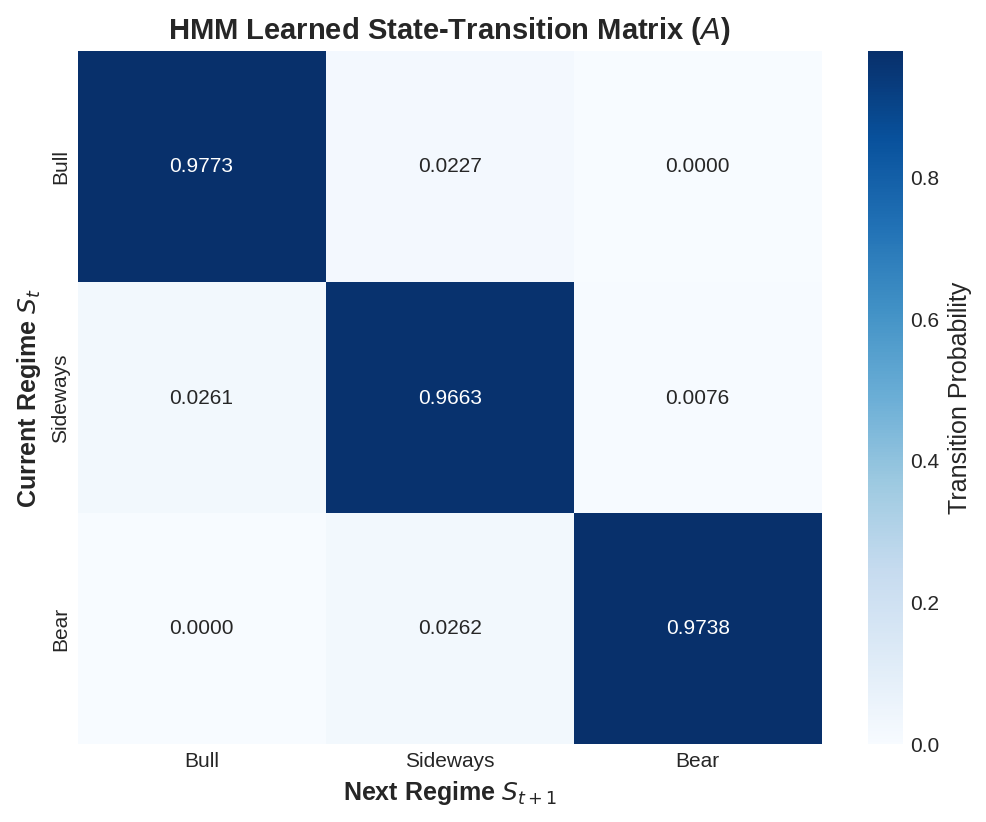

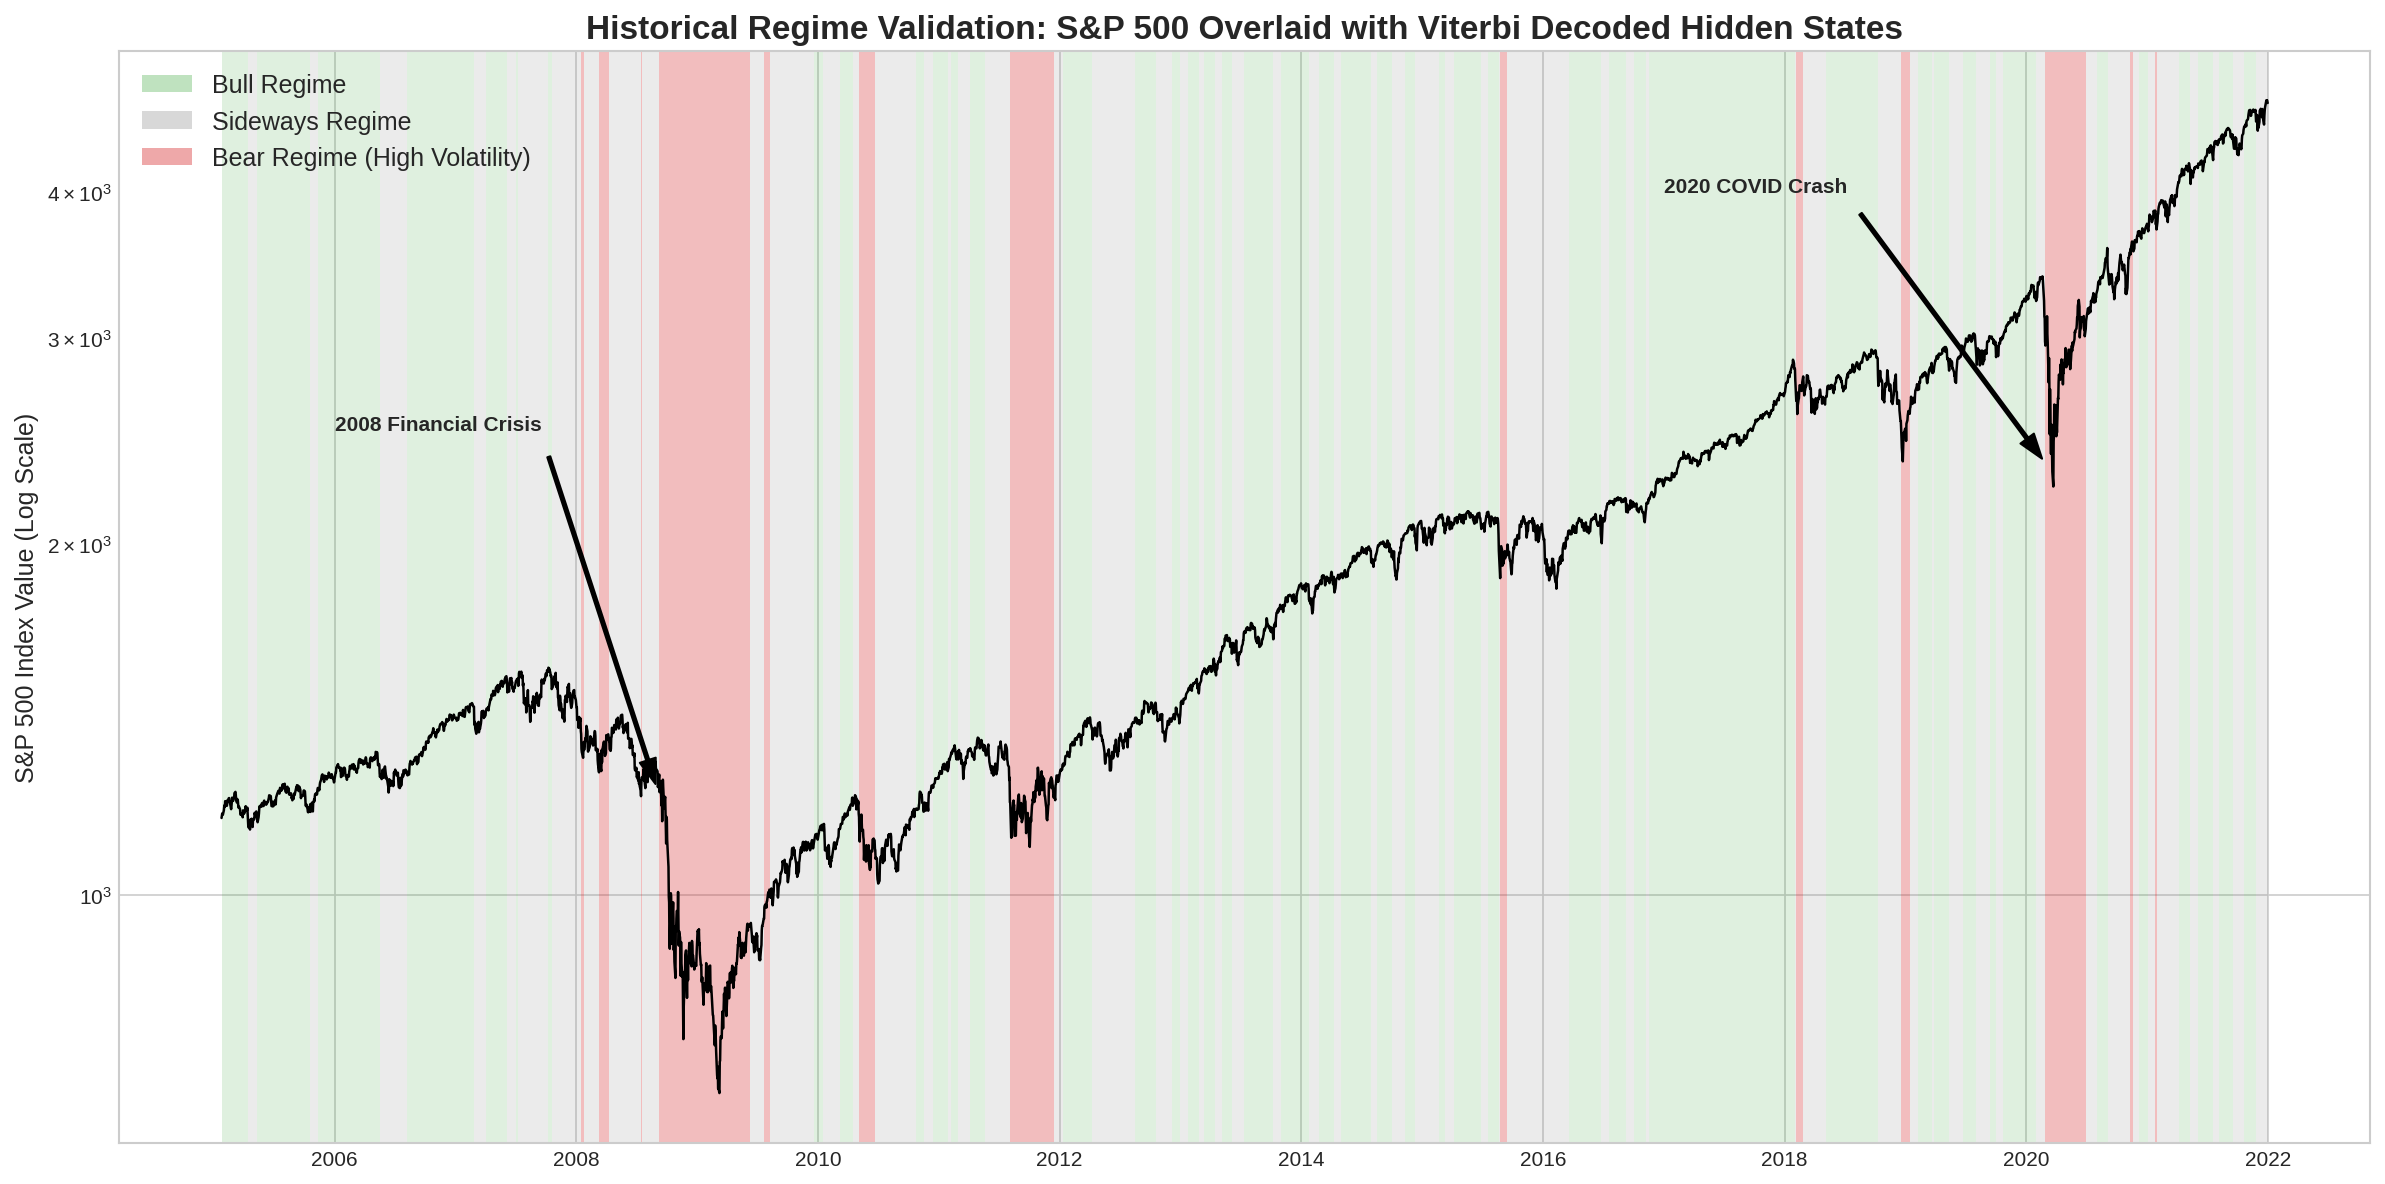

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 150})

# --- 1. Transition Matrix Heatmap ---
fig, ax = plt.subplots(figsize=(8, 6))
labels = [state_labels[i] for i in range(num_states)]

# Reorder matrix to Bull, Sideways, Bear for logical flow
order = [bull_idx, sideways_idx, bear_idx]
reordered_A = sp500_A[order, :][:, order]
reordered_labels = [state_labels[i] for i in order]

sns.heatmap(reordered_A, annot=True, fmt=".4f", cmap="Blues",
            xticklabels=reordered_labels, yticklabels=reordered_labels, ax=ax,
            cbar_kws={'label': 'Transition Probability'})
ax.set_title("HMM Learned State-Transition Matrix ($A$)", fontsize=14, fontweight='bold')
ax.set_ylabel("Current Regime $S_t$", fontweight='bold')
ax.set_xlabel("Next Regime $S_{t+1}$", fontweight='bold')
plt.show()

# --- 2. Viterbi Historical Regime Mapping ---
fig, ax = plt.subplots(figsize=(16, 8))
# Align regime indices to match train_data dates
dates = train_data.index[14:] # Accounting for the 14-day rolling window dropout
prices = train_data['Close'].iloc[14:]

# Create a continuous color block mapping for the background
# Green for Bull, Gray for Sideways, Red for Bear
color_map = {bull_idx: '#2ca02c', sideways_idx: '#7f7f7f', bear_idx: '#d62728'}
alphas = {bull_idx: 0.15, sideways_idx: 0.15, bear_idx: 0.3}

# Plot raw price
ax.plot(dates, prices, color='black', linewidth=1.2, label='S&P 500 Close Price')
ax.set_yscale('log') # Log scale for proper financial charting

# Overlay decoded regimes as background spans
current_state = sp500_regimes[0]
start_idx = 0
for i in range(1, len(sp500_regimes)):
    if sp500_regimes[i] != current_state or i == len(sp500_regimes) - 1:
        ax.axvspan(dates[start_idx], dates[i],
                   color=color_map[current_state],
                   alpha=alphas[current_state],
                   lw=0)
        start_idx = i
        current_state = sp500_regimes[i]

# Custom legend for spans
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ca02c', alpha=0.3, label='Bull Regime'),
    Patch(facecolor='#7f7f7f', alpha=0.3, label='Sideways Regime'),
    Patch(facecolor='#d62728', alpha=0.4, label='Bear Regime (High Volatility)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=12)

# Historical Validation Annotations
ax.annotate('2008 Financial Crisis', xy=(pd.Timestamp('2008-09-15'), 1200), xytext=(pd.Timestamp('2006-01-01'), 2500),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8), fontweight='bold')
ax.annotate('2020 COVID Crash', xy=(pd.Timestamp('2020-03-20'), 2300), xytext=(pd.Timestamp('2017-01-01'), 4000),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8), fontweight='bold')

ax.set_title("Historical Regime Validation: S&P 500 Overlaid with Viterbi Decoded Hidden States", fontsize=16, fontweight='bold')
ax.set_ylabel("S&P 500 Index Value (Log Scale)", fontsize=12)
plt.tight_layout()
plt.show()

### 12. System Architecture
For a Q1 journal submission or academic project defense, a programmatic architecture diagram is highly preferable to a hand-drawn flowchart. We construct the end-to-end processing pipeline of our Regime Detection system using a directed acyclic graph[cite: 7].

This maps the exact data flow: from raw S&P 500 OHLCV ingestion, through continuous feature engineering and standardization, into the Baum-Welch learning engine, and finally through Viterbi decoding for financial analysis[cite: 7].

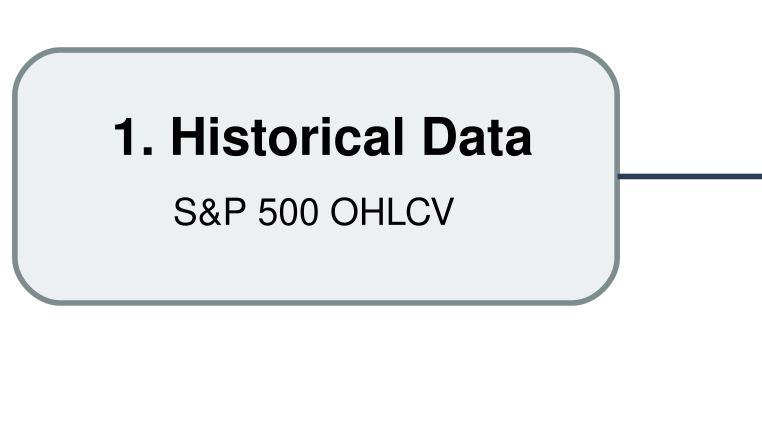

In [37]:
import graphviz
from IPython.display import display

def build_16x9_architecture():
    """
    Constructs a sophisticated U-Flow architecture diagram.
    The 3x3 grid structure enforces a strict 16:9 aspect ratio natively,
    preventing any horizontal elongation while using orthogonal splines for a schematic look.
    """
    dot = graphviz.Digraph(engine='dot')

    # Enforce 16:9 dimensions (10.66 x 6 inches) and orthogonal routing
    dot.attr(size='10.66,6!', ratio='fill', splines='ortho',
             nodesep='1.0', ranksep='1.2', dpi='300')

    # Global aesthetics for a Q1 journal/presentation standard
    dot.attr('node', shape='box', style='rounded,filled', fontname='Helvetica',
             penwidth='1.5', margin='0.3,0.2')
    dot.attr('edge', fontname='Helvetica', fontsize='11', fontcolor='#333333',
             penwidth='1.5', color='#2C3E50')

    # --- HTML NODE DEFINITIONS ---
    # Using HTML tables allows us to cleanly separate bold titles from descriptions

    # Phase 1: Top Row (Left to Right)
    # FIX: Escaped '&' as '&amp;' in the S&P 500 label to prevent Graphviz XML parser failure
    n1 = '<<TABLE BORDER="0"><TR><TD><B>1. Historical Data</B></TD></TR><TR><TD><FONT POINT-SIZE="10">S&amp;P 500 OHLCV</FONT></TD></TR></TABLE>>'
    n2 = '<<TABLE BORDER="0"><TR><TD><B>2. Feature Engineering</B></TD></TR><TR><TD><FONT POINT-SIZE="10">Returns, Volatility, Momentum</FONT></TD></TR></TABLE>>'
    n3 = '<<TABLE BORDER="0"><TR><TD><B>3. Standardization</B></TD></TR><TR><TD><FONT POINT-SIZE="10">Zero-Mean, Unit-Variance</FONT></TD></TR></TABLE>>'

    # Phase 2: Right Column & Bottom Row (EM Loop)
    n4 = '<<TABLE BORDER="0"><TR><TD><B>4. HMM Initialization</B></TD></TR><TR><TD><FONT POINT-SIZE="10">k=3 States, Gaussian Priors</FONT></TD></TR></TABLE>>'
    n5 = '<<TABLE BORDER="0"><TR><TD><B>5. Expectation (E-Step)</B></TD></TR><TR><TD><FONT POINT-SIZE="10">Forward-Backward (\u03b1, \u03b2)</FONT></TD></TR></TABLE>>'
    n6 = '<<TABLE BORDER="0"><TR><TD><B>6. Maximization (M-Step)</B></TD></TR><TR><TD><FONT POINT-SIZE="10">Update Params (\u03c0, A, \u03bc, \u03a3)</FONT></TD></TR></TABLE>>'

    # Phase 3: Bottom Left & Mid Left (Inference)
    n7 = '<<TABLE BORDER="0"><TR><TD><B>7. Viterbi Decoding</B></TD></TR><TR><TD><FONT POINT-SIZE="10">Log-Space Optimal Path</FONT></TD></TR></TABLE>>'
    n8 = '<<TABLE BORDER="0"><TR><TD><B>8. Financial Analysis</B></TD></TR><TR><TD><FONT POINT-SIZE="10">Regime Mapping &amp; Dashboard</FONT></TD></TR></TABLE>>'

    # Assign nodes with semantic coloring
    dot.node('Raw', n1, fillcolor='#ecf0f1', color='#7f8c8d')
    dot.node('Feat', n2, fillcolor='#ecf0f1', color='#7f8c8d')
    dot.node('Scale', n3, fillcolor='#ecf0f1', color='#7f8c8d')

    dot.node('Init', n4, fillcolor='#d4e6f1', color='#2980b9')
    dot.node('EStep', n5, fillcolor='#a9cce3', color='#2980b9')
    dot.node('MStep', n6, fillcolor='#a9cce3', color='#2980b9')

    dot.node('Vit', n7, fillcolor='#d5f5e3', color='#27ae60')
    dot.node('Dash', n8, fillcolor='#f9e79f', color='#f39c12')

    # Invisible center anchor to maintain the hollow 3x3 grid perfectly
    dot.node('Center', '', shape='none', width='0', height='0')

    # --- ENFORCE THE 3x3 GRID ROWS ---
    with dot.subgraph() as top_row:
        top_row.attr(rank='same')
        top_row.node('Raw'); top_row.node('Feat'); top_row.node('Scale')

    with dot.subgraph() as mid_row:
        mid_row.attr(rank='same')
        mid_row.node('Dash'); mid_row.node('Center'); mid_row.node('Init')

    with dot.subgraph() as bot_row:
        bot_row.attr(rank='same')
        bot_row.node('Vit'); bot_row.node('MStep'); bot_row.node('EStep')

    # --- ROUTE THE U-FLOW EDGES ---
    # Top Row: Left to Right
    dot.edge('Raw', 'Feat', weight='10')
    dot.edge('Feat', 'Scale', weight='10')

    # Right Column: Downward
    dot.edge('Scale', 'Init', weight='10')
    dot.edge('Init', 'EStep', weight='10')

    # Bottom Row: Right to Left (The EM Loop)
    # Use xlabel instead of label to prevent warnings under orthogonal splines
    dot.edge('EStep', 'MStep', weight='10', xlabel=' \u03b3, \u03be Posteriors')
    dot.edge('MStep', 'Vit', weight='10', xlabel=' Converged \u03bb')

    # Left Column: Upward
    dot.edge('Vit', 'Dash', weight='10')

    # The Iteration Back-Edge (M-Step back to E-Step)
    dot.edge('MStep', 'EStep', constraint='false', color='#c0392b',
             fontcolor='#c0392b', xlabel=' Iterate to Convergence', dir='back')

    # --- ENFORCE THE 3x3 GRID COLUMNS (Invisible Edges) ---
    dot.edge('Raw', 'Dash', style='invis', weight='20')
    dot.edge('Dash', 'Vit', style='invis', weight='20')

    dot.edge('Feat', 'Center', style='invis', weight='20')
    dot.edge('Center', 'MStep', style='invis', weight='20')

    return dot

# Generate the 16:9 matrix
presentation_diagram = build_16x9_architecture()

display(presentation_diagram)